# LoRa Predictive and Optimization Model

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from pathlib import Path
import warnings
import ee
import time
import json
import os
from dotenv import load_dotenv
from typing import Dict, List, Tuple, Optional, Union
import pickle
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
import logging
from dataclasses import dataclass, replace, asdict
from abc import ABC, abstractmethod

# Load environment variables
load_dotenv()
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('lora_system.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")
if torch.cuda.is_available():
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
    logger.info(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ========================================
# DATA CLASSES FOR TYPE SAFETY
# ========================================

SNR_THRESHOLD = {
        7: -7.5, 8: -10, 9: -12.5, 10: -15, 11: -17.5, 12: -20
    }

LAND_COVER_TO_K = {
    10: 0.25, 20: 0.28, 30: 0.32, 40: 0.33, 50: 0.20,
    60: 0.40, 70: 0.35, 80: 0.45, 90: 0.22, 95: 0.20, 100: 0.30
}

PENALTY_MAP = {
    10: 0.6, 20: 0.4, 30: 0.15, 40: 0.25, 50: 0.8,
    60: 0.2, 70: 0.55, 80: 0.0, 90: 0.35, 95: 0.5, 100: 0.2
}

@dataclass
class LoRaParameters:
    """LoRa communication parameters"""
    tx_power: float = 14.0  # dBm
    spreading_factor: int = 7
    frequency: float = 868.0  # MHz
    bandwidth: float = 125.0  # kHz
    coding_rate: int = 4  # 4/5

@dataclass
class PathPoint:
    """Represents a point in the path with all attributes"""
    lat: float
    lon: float
    elevation: float = 0.0
    land_cover: int = 50
    terrain_penalty: float = 0.3
    rssi: float = -100.0
    snr: float = 0.0
    pdr: float = 0.5
    path_loss: float = 100.0
    distance_to_start: float = 0.0
    distance_to_destination: float = 0.0
    grid_x: int = 0
    grid_y: int = 0
    is_relay: bool = False
    hop_number: int = 0

@dataclass
class OptimizationConfig:
    """Configuration for path optimization"""
    grid_spacing_km: float = 1.5
    max_hop_distance_km: float = 5.0
    min_relay_distance_km: float = 1.0
    interpolate_between_points: bool = True
    use_real_data: bool = True
    adaptive_grid: bool = False
    path_smoothing: bool = False

# ========================================
# 1. GOOGLE EARTH ENGINE INTEGRATION
# ========================================
class GoogleEarthEngineIntegration:
    """Robust real-time spatial data fetching from Google Earth Engine"""
    
    def __init__(self, use_service_account=False, service_account_key=None):
        self.initialized = False
        self.cache = {}
        self.rate_limiter = RateLimiter(calls_per_second=5)
        self.use_fallback = True  # Force fallback mode by default
        
        # Try to initialize with explicit error handling
        try:
            # First, try to initialize with a project ID if available
            project_id = os.getenv('GEE_PROJECT_ID')
            if project_id:
                ee.Initialize(project=project_id)
                logger.info(f"Google Earth Engine initialized with project id")
            else:
                # Try without project ID
                ee.Initialize()
                logger.info("Google Earth Engine initialized without project ID")
            
            # Test initialization with a simple request
            test_point = ee.Geometry.Point([26, 26])
            test_result = ee.Image('USGS/SRTMGL1_003').sample(test_point, scale=30).getInfo()
            
            if test_result and len(test_result['features']) > 0:
                logger.info("Google Earth Engine test successful!")
                self.initialized = True
                self.use_fallback = False  # Only use GEE if it's working
            else:
                logger.warning("Google Earth Engine test returned empty results")
                self.initialized = False
                
                
        except Exception as init_error:
            logger.warning(f"Google Earth Engine initialization failed: {init_error}")
            self.initialized = False
        
        # Land cover penalty mapping
        self.land_cover_penalties = {
                10: 0.6,   # Tree cover - HIGH penalty (dense foliage blocks RF)
                20: 0.4,   # Shrubland - MODERATE penalty
                30: 0.15,  # Grassland - LOW penalty (minimal obstruction)
                40: 0.25,  # Cropland - LOW-MODERATE penalty
                50: 0.8,  # Built-up - VERY HIGH penalty (buildings = major obstruction)
                60: 0.2,   # Bare/sparse vegetation - LOW penalty
                70: 0.55,   # Snow and ice - MODERATE-HIGH penalty (reflection/absorption)
                80: 0.0,   # Permanent water bodies - NO penalty (best for propagation)
                90: 0.35,   # Herbaceous wetland - MODERATE-HIGH penalty
                95: 0.5,   # Mangroves - HIGH penalty (dense vegetation)
                100: 0.2   # Moss and lichen - VERY LOW penalty
            }
    
    def get_elevation(self, lat: float, lon: float, retry_count=3) -> float:
        """Fetch real elevation data from SRTM (30m resolution) with retry logic"""
        if not self.initialized or self.use_fallback:
            return np.nan
        
        cache_key = f"elevation_{lat:.6f}_{lon:.6f}"
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        for attempt in range(retry_count):
            try:
                with self.rate_limiter:
                    point = ee.Geometry.Point([lon, lat])
                    srtm = ee.Image('USGS/SRTMGL1_003')
                    
                    elevation_dict = srtm.reduceRegion(
                        reducer=ee.Reducer.first(),
                        geometry=point,
                        scale=30,
                        maxPixels=1
                    ).getInfo()
                    
                    elevation = elevation_dict.get('elevation')
                    
                    if elevation is not None:
                        elevation = float(elevation)
                        self.cache[cache_key] = elevation
                        return elevation
                    else:
                        return np.nan
                        
            except Exception as e:
                if attempt == retry_count - 1:
                    logger.warning(f"Failed to get elevation for ({lat}, {lon}): {e}")
                    return np.nan
                time.sleep(0.5)
        
        return np.nan
    
    def get_land_cover(self, lat: float, lon: float, retry_count=3) -> Tuple[int, float]:
        """Fetch real land cover data from ESA WorldCover (10m resolution)"""
        if not self.initialized or self.use_fallback:
            return np.nan, np.nan
        
        cache_key = f"landcover_{lat:.6f}_{lon:.6f}"
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        for attempt in range(retry_count):
            try:
                with self.rate_limiter:
                    point = ee.Geometry.Point([lon, lat])
                    worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
                    
                    lc_dict = worldcover.reduceRegion(
                        reducer=ee.Reducer.first(),
                        geometry=point,
                        scale=10,
                        maxPixels=1
                    ).getInfo()
                    
                    land_cover = lc_dict.get('Map')
                    
                    if land_cover is not None:
                        land_cover_code = int(land_cover)
                        terrain_penalty = self.land_cover_penalties.get(land_cover_code, 0.5)
                        result = (land_cover_code, terrain_penalty)
                        self.cache[cache_key] = result
                        return result
                    else:
                        return 80, 0.0  # Water body with no penalty
                        
            except Exception as e:
                if attempt == retry_count - 1:
                    logger.warning(f"Failed to get land cover for ({lat}, {lon}): {e}")
                    return np.nan, np.nan
                time.sleep(0.5)
        
        return np.nan, np.nan
    
    def get_spatial_features(self, lat: float, lon: float) -> Dict:
        """Fetch all spatial features for a location with caching"""
        cache_key = f"spatial_{lat:.6f}_{lon:.6f}"
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        elevation = self.get_elevation(lat, lon)
        land_cover, terrain_penalty = self.get_land_cover(lat, lon)
        if np.isnan(elevation) or np.isnan(land_cover):
            raise ValueError(f"Missing spatial data at ({lat}, {lon}) — cannot proceed in real-data mode.")
        
        result = {
            'elevation': elevation,
            'land_cover': land_cover,
            'terrain_penalty': terrain_penalty
        }
        self.cache[cache_key] = result
        return result
    
    def batch_get_spatial_features(self, coordinates: List[Tuple[float, float]], 
                               batch_size: int = 50,
                               use_batch_mode: bool = True) -> List[Dict]:
        """Fetch spatial features for multiple locations using individual calls (deprecated)"""
        logger.warning("batch_get_spatial_features is deprecated. Using individual get_spatial_features calls instead.")
        
        results = []
        total = len(coordinates)
        
        for i, (lat, lon) in enumerate(coordinates):
            if i > 0 and i % batch_size == 0:
                logger.info(f"Progress: {i}/{total} ({i/total*100:.1f}%)")
            
            features = self.get_spatial_features(lat, lon)
            features['latitude'] = lat
            features['longitude'] = lon
            results.append(features)
        
        logger.info(f"Completed: {total}/{total} (100%)")
        return results

class RateLimiter:
    """Simple rate limiter for API calls"""
    def __init__(self, calls_per_second=10):
        self.calls_per_second = calls_per_second
        self.last_call = 0
        
    def __enter__(self):
        elapsed = time.time() - self.last_call
        if elapsed < 1.0 / self.calls_per_second:
            time.sleep((1.0 / self.calls_per_second) - elapsed)
        self.last_call = time.time()
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        pass

# ========================================
# 2. DATA LOADING AND PREPROCESSING
# ========================================
class LoRaDataPreprocessor:
    """Robust data loading and preprocessing with flexible format handling"""
    
    def __init__(self, gee_integration: Optional[GoogleEarthEngineIntegration] = None):
        self.scaler = StandardScaler()
        self.gee = gee_integration
        
    def load_dataset1(self, filepath):
        """Load dataset with format: latitude,longitude,elevation,land_cover,etc."""
        try:
            # Try different separators
            for sep in [',', '|', '\t']:
                try:
                    df = pd.read_csv(filepath, sep=sep)
                    if len(df.columns) > 5:  # Reasonable number of columns
                        break
                except:
                    continue
            else:
                raise ValueError("Could not determine file format")
            
            # Map column names flexibly
            column_mapping = {
                'latitude': ['latitude', 'lat'],
                'longitude': ['longitude', 'lon'],
                'elevation': ['elevation', 'altitude', 'elev'],
                'land_cover': ['land_cover', 'land_cover_code', 'landcover'],
                'terrain_penalty': ['terrain_penalty', 'terrain'],
                'RSSI': ['RSSI', 'rssi'],
                'SNR': ['SNR', 'snr'],
                'PDR': ['PDR', 'pdr'],
                'observed_path_loss': ['observed_path_loss', 'path_loss', 'loss'],
                'spreading_factor': ['spreading_factor', 'sf'],
                'frequency': ['frequency', 'freq'],
                'tx_power': ['tx_power', 'power'],
                'distance_to_start': ['distance_to_start'],
                'distance_to_destination': ['distance_to_destination']
            }
            
            # Create standardized dataframe
            df_processed = pd.DataFrame()
            for std_col, possible_cols in column_mapping.items():
                for col in possible_cols:
                    if col in df.columns:
                        df_processed[std_col] = df[col]
                        break
                else:
                    # Set default values if column not found
                    if std_col == 'spreading_factor':
                        df_processed[std_col] = 7
                    elif std_col == 'frequency':
                        df_processed[std_col] = 868
                    elif std_col == 'tx_power':
                        df_processed[std_col] = 14
                    elif std_col in ['terrain_penalty']:
                        df_processed[std_col] = 0.3
                    else:
                        df_processed[std_col] = 0
            
            return df_processed.dropna(subset=['RSSI', 'SNR', 'PDR'])
        
        except Exception as e:
            logger.error(f"Error loading dataset: {e}")
            return pd.DataFrame()
    
    def load_dataset2(self, filepath):
        """Load dataset with format: device_id,gateway_id,latitude,longitude,altitude,etc."""
        try:
            # Try different separators
            for sep in [',', '|', '\t']:
                try:
                    df = pd.read_csv(filepath, sep=sep)
                    if len(df.columns) > 5:  # Reasonable number of columns
                        break
                except:
                    continue
            else:
                raise ValueError("Could not determine file format")
            
            # Map column names flexibly
            column_mapping = {
                'latitude': ['latitude', 'lat'],
                'longitude': ['longitude', 'lon'],
                'elevation': ['altitude', 'elevation', 'elev'],
                'land_cover': ['land_cover_code', 'land_cover', 'landcover'],
                'terrain_penalty': ['terrain_penalty', 'terrain'],
                'RSSI': ['RSSI', 'rssi'],
                'SNR': ['SNR', 'snr'],
                'PDR': ['PDR', 'pdr'],
                'observed_path_loss': ['observed_path_loss', 'path_loss', 'loss'],
                'spreading_factor': ['spreading_factor', 'sf'],
                'frequency': ['frequency', 'freq'],
                'tx_power': ['tx_power', 'power'],
                'distance_to_start': ['distance_to_start'],
                'distance_to_destination': ['distance_to_destination']
            }
            
            # Create standardized dataframe
            df_processed = pd.DataFrame()
            for std_col, possible_cols in column_mapping.items():
                for col in possible_cols:
                    if col in df.columns:
                        df_processed[std_col] = df[col]
                        break
                else:
                    # Set default values if column not found
                    if std_col == 'spreading_factor':
                        df_processed[std_col] = 7
                    elif std_col == 'frequency':
                        df_processed[std_col] = 868
                    elif std_col == 'tx_power':
                        df_processed[std_col] = 14
                    elif std_col in ['terrain_penalty']:
                        df_processed[std_col] = 0.3
                    else:
                        df_processed[std_col] = 0
            
            return df_processed.dropna(subset=['RSSI', 'SNR', 'PDR'])
        
        except Exception as e:
            logger.error(f"Error loading dataset: {e}")
            return pd.DataFrame()
    
    def merge_datasets(self, df1, df2):
        """Merge and clean datasets with validation"""
        if df1.empty and df2.empty:
            raise ValueError("Both datasets are empty!")
        
        if df1.empty:
            df_combined = df2.copy()
        elif df2.empty:
            df_combined = df1.copy()
        else:
            df_combined = pd.concat([df1, df2], ignore_index=True)
        
        # Drop rows with critical missing values
        df_combined = df_combined.dropna(subset=['RSSI', 'SNR', 'PDR'])
        
        # Feature engineering
        df_combined['distance_total'] = df_combined['distance_to_start'] + df_combined['distance_to_destination']
        df_combined['elevation_normalized'] = df_combined['elevation'] / 1000
        df_combined['rssi_normalized'] = (df_combined['RSSI'] + 130) / 100
        
        # Add default values if columns don't exist
        if 'frequency' not in df_combined.columns:
            df_combined['frequency'] = 868  # Default EU868
            logger.warning(" 'frequency' column not found, using default 868 MHz")
        
        if 'tx_power' not in df_combined.columns:
            df_combined['tx_power'] = 14  # Default 14 dBm
            logger.warning(" 'tx_power' column not found, using default 14 dBm")
        
        logger.info(f"Combined dataset shape: {df_combined.shape}")
        logger.info(f"Missing values:\n{df_combined.isnull().sum()}")
        
        return df_combined
    
    def prepare_features(self, df, target_cols=['RSSI', 'SNR', 'observed_path_loss']):
        feature_cols = [
            'elevation', 'land_cover', 'terrain_penalty',
            'distance_to_start', 'distance_to_destination',
            'spreading_factor', 'frequency', 'tx_power',
            'distance_total', 'elevation_normalized'
        ]
        
        # Validate all feature columns exist
        missing_cols = [col for col in feature_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing feature columns: {missing_cols}")
        
        X = df[feature_cols].values
        y = df[target_cols].values
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        logger.info(f"Training samples: {len(X_train)}")
        logger.info(f"Test samples: {len(X_test)}")
        logger.info(f"Features: {len(feature_cols)}")
        
        return X_train_scaled, X_test_scaled, y_train, y_test, feature_cols

# ========================================
# 3. PYTORCH NEURAL NETWORK MODEL
# ========================================
class LoRaDataset(Dataset):
    """PyTorch dataset for LoRa data"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LoRaNeuralNetwork(nn.Module):
    """Advanced neural network with configurable architecture"""
    def __init__(self, input_size, output_size, config=None):
        super(LoRaNeuralNetwork, self).__init__()
        
        # Default configuration
        default_config = {
            'hidden_sizes': [256, 128, 64, 32],
            'dropout_rate': 0.3,
            'activation': 'relu',
            'batch_norm': True,
            'residual_connections': True
        }
        
        if config:
            default_config.update(config)
        
        self.config = default_config
        layers = []
        prev_size = input_size
        
        for i, hidden_size in enumerate(self.config['hidden_sizes']):
            layers.append(nn.Linear(prev_size, hidden_size))
            
            if self.config['batch_norm']:
                layers.append(nn.BatchNorm1d(hidden_size))
            
            if self.config['activation'] == 'relu':
                layers.append(nn.ReLU())
            elif self.config['activation'] == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.2))
            elif self.config['activation'] == 'elu':
                layers.append(nn.ELU())
            
            if self.config['dropout_rate'] > 0:
                layers.append(nn.Dropout(self.config['dropout_rate']))
            
            # Add residual connection for deeper networks
            if self.config['residual_connections'] and i > 0 and prev_size == hidden_size:
                layers.append(ResidualConnection())
            
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

    def predict(self, X):
        """Make predictions with the model"""
        self.eval()
        with torch.no_grad():
            if isinstance(X, np.ndarray):
                X = torch.FloatTensor(X)
            X = X.to(next(self.parameters()).device)
            predictions = self.forward(X).cpu().numpy()
        return predictions

class ResidualConnection(nn.Module):
    """Residual connection for deeper networks"""
    def __init__(self):
        super(ResidualConnection, self).__init__()
        
    def forward(self, x):
        return x

class NeuralNetworkTrainer:
    """Advanced neural network trainer with early stopping and learning rate scheduling"""
    def __init__(self, input_size, output_size, device, config=None):
        self.device = device
        self.config = config or {}
        
        # Model configuration
        model_config = self.config.get('model', {})
        # Only predict 3 values: RSSI, SNR, and path_loss (NO PDR)
        self.model = LoRaNeuralNetwork(input_size, 3, model_config).to(device)
        
        # Training configuration
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(
            self.model.parameters(), 
            lr=self.config.get('learning_rate', 0.001),
            weight_decay=self.config.get('weight_decay', 1e-5)
        )
        
        # Learning rate scheduling
        scheduler_type = self.config.get('scheduler', 'reduce_on_plateau')
        if scheduler_type == 'reduce_on_plateau':
            self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer, mode='min', patience=10, factor=0.5, verbose=True
            )
        elif scheduler_type == 'cosine':
            self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer, T_max=self.config.get('epochs', 100)
            )
        
        # Early stopping
        self.early_stopping_patience = self.config.get('early_stopping_patience', 20)
        self.early_stopping_counter = 0
        self.best_val_loss = float('inf')
        
        self.train_losses = []
        self.val_losses = []
        
    def train(self, train_loader, val_loader, epochs=None):
        """Train the neural network with early stopping"""
        epochs = epochs or self.config.get('epochs', 100)
        logger.info(f"\nTraining Neural Network on {self.device}...")
        logger.info(f"Model architecture: {self.model.config}")
        logger.info(f"Training configuration: {self.config}")
        
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            train_loss = 0
            train_steps = 0
            
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                self.optimizer.zero_grad()
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                
                # Gradient clipping
                if self.config.get('gradient_clip', 0) > 0:
                    nn.utils.clip_grad_norm_(self.model.parameters(), self.config['gradient_clip'])
                
                self.optimizer.step()
                
                train_loss += loss.item()
                train_steps += 1
            
            train_loss /= train_steps
            self.train_losses.append(train_loss)
            
            # Validation phase
            self.model.eval()
            val_loss = 0
            val_steps = 0
            
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    outputs = self.model(X_batch)
                    loss = self.criterion(outputs, y_batch)
                    val_loss += loss.item()
                    val_steps += 1
            
            val_loss /= val_steps
            self.val_losses.append(val_loss)
            
            # Learning rate scheduling
            if isinstance(self.scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_loss)
            else:
                self.scheduler.step()
            
            # Early stopping
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.early_stopping_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_model.pth')
            else:
                self.early_stopping_counter += 1
                if self.early_stopping_counter >= self.early_stopping_patience:
                    logger.info(f"Early stopping at epoch {epoch+1}")
                    # Load best model
                    self.model.load_state_dict(torch.load('best_model.pth'))
                    break
            
            if (epoch + 1) % 10 == 0:
                logger.info(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        logger.info("Neural Network training completed!")
        
    def predict(self, X):
        """Make predictions with the trained model"""
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.model(X_tensor).cpu().numpy()
        return predictions

# ========================================
# 4. RANDOM FOREST MODEL
# ========================================
class RandomForestModel:
    """Random Forest model with feature importance"""
    def __init__(self, n_estimators=100):
        self.models = {
            'RSSI': RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1),
            'SNR': RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1),
            'path_loss': RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
        }
        
    def train(self, X_train, y_train):
        """Train all Random Forest models"""
        logger.info("\nTraining Random Forest models...")
        for i, (name, model) in enumerate(self.models.items()):
            logger.info(f"Training {name} model...")
            model.fit(X_train, y_train[:, i])
        logger.info("Random Forest training completed!")
        
    def predict(self, X):
        """Make predictions with all models"""
        predictions = np.zeros((X.shape[0], len(self.models)))
        for i, model in enumerate(self.models.values()):
            predictions[:, i] = model.predict(X)
        return predictions
    
    def get_feature_importance(self, feature_names):
        """Get feature importance for all models"""
        importance_dict = {}
        for name, model in self.models.items():
            importance_dict[name] = dict(zip(feature_names, model.feature_importances_))
        return importance_dict

# ========================================
# 5. XGBOOST MODEL
# ========================================
class XGBoostModel:
    """XGBoost model with advanced configuration"""
    def __init__(self):
        self.models = {
            'RSSI': xgb.XGBRegressor(
                n_estimators=100, 
                learning_rate=0.1, 
                max_depth=6, 
                random_state=42,
                n_jobs=-1
            ),
            'SNR': xgb.XGBRegressor(
                n_estimators=100, 
                learning_rate=0.1, 
                max_depth=6, 
                random_state=42,
                n_jobs=-1
            ),
            'path_loss': xgb.XGBRegressor(
                n_estimators=100, 
                learning_rate=0.1, 
                max_depth=6, 
                random_state=42,
                n_jobs=-1
            )
        }
        
    def train(self, X_train, y_train):
        """Train all XGBoost models"""
        logger.info("\nTraining XGBoost models...")
        for i, (name, model) in enumerate(self.models.items()):
            logger.info(f"Training {name} model...")
            model.fit(X_train, y_train[:, i])
        logger.info("XGBoost training completed!")
        
    def predict(self, X):
        """Make predictions with all models"""
        predictions = np.zeros((X.shape[0], len(self.models)))
        for i, model in enumerate(self.models.values()):
            predictions[:, i] = model.predict(X)
        return predictions

# ========================================
# 1. ENSEMBLE MODEL - Combines All Models
# ========================================

class EnsembleModel:
    """
    Ensemble that combines Neural Network, Random Forest, and XGBoost.
    Uses weighted voting based on validation performance.
    """
    
    def __init__(self, models_dict, device=None):
        """
        Args:
            models_dict: {'nn': model, 'rf': model, 'xgb': model}
            device: PyTorch device (for NN)
        """
        self.models = models_dict
        self.device = device
        self.weights = None
        
    def calculate_optimal_weights(self, X_val, y_val):
        """Calculate optimal weights based on validation performance"""
        performances = {}
        
        for name, model in self.models.items():
            pred = self._predict_single(name, model, X_val)
            r2_scores = [r2_score(y_val[:, i], pred[:, i]) for i in range(y_val.shape[1])]
            avg_r2 = np.mean(r2_scores)
            performances[name] = avg_r2
            logger.info(f"  {name}: R² = {avg_r2:.4f}")
        
        # Convert to weights (softmax)
        total = sum(np.exp(r2 * 5) for r2 in performances.values())
        self.weights = {
            name: np.exp(performances[name] * 5) / total 
            for name in self.models.keys()
        }
        
        logger.info("\nEnsemble Weights:")
        for name, weight in self.weights.items():
            logger.info(f"  {name}: {weight:.3f}")
    
    def _predict_single(self, name, model, X):
        """Predict with a single model"""
        if name == 'nn':
            # Neural Network
            import torch
            model.eval()
            with torch.no_grad():
                X_tensor = torch.FloatTensor(X).to(self.device)
                return model(X_tensor).cpu().numpy()
        else:
            # Sklearn models (RF, XGB)
            return model.predict(X)
    
    def predict(self, X):
        """Ensemble prediction (weighted average)"""
        if self.weights is None:
            # Equal weights if not calculated
            self.weights = {name: 1.0/len(self.models) for name in self.models.keys()}
        
        # Get predictions from all models
        predictions = {}
        for name, model in self.models.items():
            predictions[name] = self._predict_single(name, model, X)
        
        # Weighted average
        ensemble_pred = np.zeros_like(predictions[list(self.models.keys())[0]])
        for name, pred in predictions.items():
            ensemble_pred += pred * self.weights[name]
        
        return ensemble_pred
    
class BestModelSelector:
    """
    Evaluates all models and selects the best one.
    Also creates and evaluates ensemble.
    """
    
    def __init__(self, device):
        self.device = device
        self.models = {}
        self.performances = {}
        self.best_model = None
        self.best_name = None
        
    def add_model(self, name, model):
        """Add a trained model"""
        self.models[name] = model
    
    def evaluate_all(self, X_test, y_test):
        """Evaluate all models and select best"""
        logger.info("\n" + "="*70)
        logger.info("EVALUATING ALL MODELS")
        logger.info("="*70)
        
        metrics_names = ['RSSI', 'SNR', 'path_loss']
        
        for model_name in list(self.models.keys()):
            model = self.models[model_name]
            
            # Get predictions
            if model_name == 'Neural_Network':
                model.eval()
                import torch
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X_test).to(self.device)
                    y_pred = model(X_tensor).cpu().numpy()
            else:
                y_pred = model.predict(X_test)
            
            # Calculate metrics
            performance = {}
            logger.info(f"\n{model_name}:")
            
            for i, metric_name in enumerate(metrics_names):
                mse = mean_squared_error(y_test[:, i], y_pred[:, i])
                r2 = r2_score(y_test[:, i], y_pred[:, i])
                
                performance[f'{metric_name}_mse'] = mse
                performance[f'{metric_name}_r2'] = r2
                
                logger.info(f"  {metric_name}: MSE={mse:.4f}, R²={r2:.4f}")
            
            # Calculate average R²
            avg_r2 = np.mean([performance[f'{m}_r2'] for m in metrics_names])
            performance['average_r2'] = avg_r2
            self.performances[model_name] = performance
            
            logger.info(f"  Average R²: {avg_r2:.4f}")
    
    def create_ensemble(self, X_val, y_val):
        """Create and evaluate ensemble model"""
        logger.info("\n" + "="*70)
        logger.info("CREATING ENSEMBLE MODEL")
        logger.info("="*70)
        
        if len(self.models) < 2:
            logger.warning("Need at least 2 models for ensemble")
            return
        
        # Create ensemble
        models_for_ensemble = {
            'nn': self.models.get('Neural_Network'),
            'rf': self.models.get('Random_Forest'),
            'xgb': self.models.get('XGBoost')
        }
        # Remove None values
        models_for_ensemble = {k: v for k, v in models_for_ensemble.items() if v is not None}
        
        ensemble = EnsembleModel(models_for_ensemble, self.device)
        ensemble.calculate_optimal_weights(X_val, y_val)
        
        # Evaluate ensemble
        logger.info("\nEvaluating Ensemble:")
        y_pred = ensemble.predict(X_val)
        
        performance = {}
        metrics_names = ['RSSI', 'SNR', 'path_loss']
        
        for i, metric_name in enumerate(metrics_names):
            mse = mean_squared_error(y_val[:, i], y_pred[:, i])
            r2 = r2_score(y_val[:, i], y_pred[:, i])
            
            performance[f'{metric_name}_mse'] = mse
            performance[f'{metric_name}_r2'] = r2
            
            logger.info(f"  {metric_name}: MSE={mse:.4f}, R²={r2:.4f}")
        
        avg_r2 = np.mean([performance[f'{m}_r2'] for m in metrics_names])
        performance['average_r2'] = avg_r2
        logger.info(f"  Average R²: {avg_r2:.4f}")
        
        self.models['Ensemble'] = ensemble
        self.performances['Ensemble'] = performance
    
    def select_best(self):
        """Select best model based on average R²"""
        logger.info("\n" + "="*70)
        logger.info("SELECTING BEST MODEL")
        logger.info("="*70)
        
        best_r2 = -1
        for name, perf in self.performances.items():
            if perf['average_r2'] > best_r2:
                best_r2 = perf['average_r2']
                self.best_name = name
                self.best_model = self.models[name]
        
        logger.info(f"\nBEST MODEL: {self.best_name}")
        logger.info(f"Average R²: {best_r2:.4f}")
        
        return self.best_model, self.best_name
    
    def save_best_model(self, scaler, feature_cols, output_dir='./models'):
        """Save best model and metadata"""
        output_path = Path(output_dir)
        output_path.mkdir(exist_ok=True, parents=True)
        
        # Save model
        model_file = output_path / 'best_model.pkl'
        with open(model_file, 'wb') as f:
            pickle.dump(self.best_model, f)
        logger.info(f"\nSaved best model: {model_file}")
        
        # Save scaler
        scaler_file = output_path / 'scaler.pkl'
        with open(scaler_file, 'wb') as f:
            pickle.dump(scaler, f)
        logger.info(f"Saved scaler: {scaler_file}")
        
        # Save metadata
        metadata = {
            'best_model_name': self.best_name,
            'performance': self.performances[self.best_name],
            'all_performances': self.performances,
            'feature_columns': feature_cols
        }
        
        metadata_file = output_path / 'model_metadata.json'
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)
        logger.info(f"Saved metadata: {metadata_file}")
            
# ========================================
# 6. PATH OPTIMIZATION WITH REAL-TIME GEE DATA
# ========================================
class PathOptimizer:
    """Advanced path optimization with adaptive grid and terrain interpolation"""
    
    def __init__(self, model, scaler, feature_cols, gee_integration: GoogleEarthEngineIntegration):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.gee = gee_integration
        
        # LoRa-specific parameters
        self.lora_params = {
            'sensitivity': {7: -123, 8: -126, 9: -129, 10: -132, 11: -134, 12: -137},
            'max_distance': {7: 15000, 8: 7500, 9: 3750, 10: 1875, 11: 937, 12: 468}
        }

    def calculate_distance(self, lat1, lon1, lat2, lon2):
        """Calculate Haversine distance in meters"""
        R = 6371000
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        
        a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        
        return R * c

    def _calculate_bearing(self, lat1, lon1, lat2, lon2):
        """Calculate bearing between two points"""
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        x = np.sin(dlon) * np.cos(lat2)
        y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
        bearing = np.arctan2(x, y)
        return (np.degrees(bearing) + 360) % 360

    def _destination_point(self, lat, lon, distance_m, bearing_deg):
        """Calculate destination point given distance and bearing"""
        R = 6371000
        lat1 = np.radians(lat)
        lon1 = np.radians(lon)
        brng = np.radians(bearing_deg)
        d = distance_m / R
        
        lat2 = np.arcsin(np.sin(lat1) * np.cos(d) + np.cos(lat1) * np.sin(d) * np.cos(brng))
        lon2 = lon1 + np.arctan2(
            np.sin(brng) * np.sin(d) * np.cos(lat1),
            np.cos(d) - np.sin(lat1) * np.sin(lat2)
        )
        return np.degrees(lat2), np.degrees(lon2)

    def snr_to_pdr(self, snr, spreading_factor, land_cover_code):
        """
        Calculate PDR from SNR - EXACT match to your preprocessing function.
        This is physics-based, not ML prediction!
        """
        snr_threshold = SNR_THRESHOLD.get(spreading_factor, -7.5)
        margin = snr - snr_threshold
        
        if margin <= 0:
            return 0.0
        
        k = LAND_COVER_TO_K.get(land_cover_code, 0.3)
        pdr = 1 - np.exp(-k * margin)
        return max(0.0, min(1.0, pdr))

    def generate_adaptive_grid(self, start_lat, start_lon, dest_lat, dest_lon, config):
        """
        Generate ROBUST grid with 1-2 km spacing between segments.
        First beacon will be at segment 1 (not segment 0).
        """
        total_distance = self.calculate_distance(start_lat, start_lon, dest_lat, dest_lon)
        bearing = self._calculate_bearing(start_lat, start_lon, dest_lat, dest_lon)
        perpendicular_bearing = (bearing + 90) % 360
        
        # Fixed 1.5 km spacing between segments
        segment_spacing_m = 1500
        num_segments = max(3, int(np.ceil(total_distance / segment_spacing_m)))
        
        # Adaptive corridor width and lanes based on distance
        if total_distance < 3000:
            corridor_width_km = 2.0
            num_lanes = 9
        elif total_distance < 8000:
            corridor_width_km = 4.0
            num_lanes = 11
        else:
            corridor_width_km = 6.0
            num_lanes = 15
        
        logger.info(f"\n Grid Configuration (User-Input Driven):")
        logger.info(f"  Total distance: {total_distance/1000:.2f} km")
        logger.info(f"  Segment spacing: 1.5 km (fixed)")
        logger.info(f"  Number of segments: {num_segments}")
        logger.info(f"  Corridor width: ±{corridor_width_km/2:.2f} km")
        logger.info(f"  Lanes per segment: {num_lanes}")
        logger.info(f"  Total grid points: {num_segments * num_lanes}")
        logger.info(f"  First beacon location: Segment 1 (~1.5 km from transmitter)")
        
        # Generate grid
        grid_points = []
        coordinates = []
        lane_offsets = np.linspace(-corridor_width_km/2, corridor_width_km/2, num_lanes) * 1000
        
        for segment_idx in range(num_segments):
            progress = segment_idx / (num_segments - 1) if num_segments > 1 else 0
            center_lat = start_lat + progress * (dest_lat - start_lat)
            center_lon = start_lon + progress * (dest_lon - start_lon)
            
            for lane_idx, offset_m in enumerate(lane_offsets):
                lat, lon = self._destination_point(center_lat, center_lon, offset_m, perpendicular_bearing)
                
                point = PathPoint(
                    lat=lat,
                    lon=lon,
                    grid_x=segment_idx,
                    grid_y=lane_idx
                )
                grid_points.append(point)
                coordinates.append((lat, lon))
        
        return grid_points, coordinates, num_segments, num_lanes

    def predict_at_point(self, point, start_lat, start_lon, dest_lat, dest_lon, lora_params):
        """
        Predict metrics at a point using USER-PROVIDED parameters.
        
        Process:
        1. Get real terrain data from GEE (elevation, land_cover)
        2. Use ML model to predict RSSI, SNR, path_loss
        3. CALCULATE PDR from SNR using physics formula
        
        User parameters used:
        - lora_params.spreading_factor  affects SNR threshold and PDR
        - lora_params.frequency  used in ML model features
        - lora_params.tx_power  used in ML model features
        """
        # Calculate distances
        point.distance_to_start = self.calculate_distance(
            point.lat, point.lon, start_lat, start_lon
        )
        point.distance_to_destination = self.calculate_distance(
            point.lat, point.lon, dest_lat, dest_lon
        )
        distance_total = point.distance_to_start + point.distance_to_destination
        
        # Get REAL spatial features from GEE
        spatial = self.gee.get_spatial_features(point.lat, point.lon)
        point.elevation = spatial['elevation']
        point.land_cover = spatial['land_cover']
        point.terrain_penalty = spatial['terrain_penalty']
        
        # Create feature vector using USER INPUT parameters
        features = np.array([[
            point.elevation,                    # From GEE
            point.land_cover,                   # From GEE
            point.terrain_penalty,              # From GEE
            point.distance_to_start,            # Calculated
            point.distance_to_destination,      # Calculated
            lora_params.spreading_factor,       # USER INPUT ←
            lora_params.frequency,              # USER INPUT ←
            lora_params.tx_power,               # USER INPUT ←
            distance_total,                     # Calculated
            point.elevation / 1000              # Normalized elevation
        ]])
        
        # ML model predicts: RSSI, SNR, path_loss (NOT PDR!)
        features_scaled = self.scaler.transform(features)
        predictions = self.model.predict(features_scaled)[0]
        
        point.rssi = np.clip(predictions[0], -150, -20)
        point.snr = predictions[1]
        point.path_loss = predictions[2]
        
        # CALCULATE PDR from SNR using physics (USER's SF affects this!)
        point.pdr = self.snr_to_pdr(
            point.snr,
            lora_params.spreading_factor,  # USER INPUT affects PDR ←
            point.land_cover
        )
        
        point.distance_to_goal = point.distance_to_destination
        
        return point

    def calculate_lora_cost(self, point, distance, lora_params):
        """
        Calculate path cost for A* algorithm.
        Uses CALCULATED PDR (which depends on user's SF choice).
        """
        # Primary: PDR cost (exponential penalty for poor signal)
        if point.pdr < 0.1:
            return 1000.0  # Blocked
        elif point.pdr < 0.2:
            pdr_cost = 50.0
        elif point.pdr < 0.4:
            pdr_cost = 10.0
        elif point.pdr < 0.6:
            pdr_cost = 3.0
        elif point.pdr < 0.8:
            pdr_cost = 1.0
        else:
            pdr_cost = 0.1
        
        # Distance cost
        distance_cost = distance / 2000
        
        # Terrain cost
        terrain_cost = point.terrain_penalty * 0.5
        
        return pdr_cost + distance_cost * 0.2 + terrain_cost * 0.3

    def find_optimal_path(self, start_lat, start_lon, dest_lat, dest_lon,
                        lora_params, config):
        """
        Find optimal beacon placement path using USER INPUTS.
        
        User inputs affect:
        - Grid generation (based on distance between start/dest)
        - RSSI/SNR prediction (uses TX power, frequency, SF in model)
        - PDR calculation (SF determines SNR threshold)
        - Path cost (better SF = better PDR = lower cost)
        """
        logger.info("\n" + "="*70)
        logger.info("  PATH OPTIMIZATION WITH USER PARAMETERS")
        logger.info("="*70)
        logger.info(f"  Start: ({start_lat:.6f}, {start_lon:.6f})")
        logger.info(f"  Destination: ({dest_lat:.6f}, {dest_lon:.6f})")
        logger.info(f"  TX Power: {lora_params.tx_power} dBm")
        logger.info(f"  Spreading Factor: SF{lora_params.spreading_factor}")
        logger.info(f"  Frequency: {lora_params.frequency} MHz")
        
        # Generate grid (spacing based on distance)
        grid_points, coordinates, num_segments, num_lanes = \
            self.generate_adaptive_grid(start_lat, start_lon, dest_lat, dest_lon, config)
        
        # Fetch REAL spatial data from GEE
        if config.use_real_data:
            logger.info("\n Fetching real spatial data from Google Earth Engine...")
            total = len(coordinates)
            for i, (lat, lon) in enumerate(coordinates):
                if i > 0 and i % 50 == 0:
                    logger.info(f"  Progress: {i}/{total} ({i/total*100:.0f}%)")
                
                features = self.gee.get_spatial_features(lat, lon)
                grid_points[i].elevation = features['elevation']
                grid_points[i].land_cover = features['land_cover']
                grid_points[i].terrain_penalty = features['terrain_penalty']
            
            logger.info(f" Completed: {total}/{total}")
        
        # Predict RSSI/SNR using USER parameters, CALCULATE PDR
        logger.info("\n Predicting metrics with user parameters...")
        logger.info(f"  Using SF{lora_params.spreading_factor}  SNR threshold: "
                f"{SNR_THRESHOLD[lora_params.spreading_factor]} dB")
        
        for point in grid_points:
            self.predict_at_point(point, start_lat, start_lon, dest_lat, dest_lon, lora_params)
        
        logger.info(f" Predictions completed")
        
        # Log PDR statistics
        all_pdrs = [p.pdr for p in grid_points]
        logger.info(f"  PDR range: [{min(all_pdrs):.3f}, {max(all_pdrs):.3f}], "
                f"avg: {np.mean(all_pdrs):.3f}")
        
        # A* pathfinding - START FROM SEGMENT 1 (not 0)
        logger.info("\n Running A* pathfinding...")
        logger.info(f"  Transmitter at: ({start_lat:.6f}, {start_lon:.6f})")
        
        # Find starting node at segment 1, center lane
        start_candidates = [p for p in grid_points if p.grid_x == 1]
        start_node = min(start_candidates, key=lambda p: abs(p.grid_y - num_lanes//2))
        
        logger.info(f"  First beacon at: ({start_node.lat:.6f}, {start_node.lon:.6f})")
        logger.info(f"  Distance to first beacon: {start_node.distance_to_start/1000:.2f} km")
        
        open_set = [start_node]
        closed_set = set()
        came_from = {}
        g_score = {id(start_node): 0}
        f_score = {id(start_node): start_node.distance_to_goal}
        
        iterations = 0
        
        while open_set:
            iterations += 1
            current = min(open_set, key=lambda x: f_score.get(id(x), float('inf')))
            
            # Reached destination?
            if current.grid_x == num_segments - 1:
                # Reconstruct path
                path = [current]
                while id(current) in came_from:
                    current = came_from[id(current)]
                    path.insert(0, current)
                
                logger.info(f"\n OPTIMAL PATH FOUND!")
                logger.info(f"  Iterations: {iterations}")
                logger.info(f"  Beacon count: {len(path)}")
                logger.info(f"  Segments: {path[0].grid_x}  {path[-1].grid_x}")
                
                # Path statistics
                avg_pdr = np.mean([p.pdr for p in path])
                min_pdr = min([p.pdr for p in path])
                avg_snr = np.mean([p.snr for p in path])
                avg_rssi = np.mean([p.rssi for p in path])
                
                logger.info(f"\n   Path Quality:")
                logger.info(f"  Average PDR: {avg_pdr:.3f} ({avg_pdr*100:.1f}%)")
                logger.info(f"  Minimum PDR: {min_pdr:.3f} ({min_pdr*100:.1f}%)")
                logger.info(f"  Average SNR: {avg_snr:.2f} dB")
                logger.info(f"  Average RSSI: {avg_rssi:.1f} dBm")
                
                # Calculate total path distance
                total_path_dist = sum(
                    self.calculate_distance(path[i].lat, path[i].lon, 
                                        path[i+1].lat, path[i+1].lon)
                    for i in range(len(path)-1)
                )
                logger.info(f"  Total path distance: {total_path_dist/1000:.2f} km")
                
                # Check if path deviates from direct line
                direct_dist = self.calculate_distance(start_lat, start_lon, dest_lat, dest_lon)
                deviation = ((total_path_dist - direct_dist) / direct_dist) * 100
                logger.info(f"  Path deviation: +{deviation:.1f}% from direct line")
                
                # Path does NOT include transmitter (starts at segment 1)
                return path, grid_points
            
            open_set.remove(current)
            closed_set.add(id(current))
            
            # Forward-only neighbors
            neighbors = [
                p for p in grid_points 
                if p.grid_x == current.grid_x + 1
                and id(p) not in closed_set
            ]
            
            for neighbor in neighbors:
                distance = self.calculate_distance(
                    current.lat, current.lon,
                    neighbor.lat, neighbor.lon
                )
                
                cost = self.calculate_lora_cost(neighbor, distance, lora_params)
                
                # Penalize excessive zigzagging
                lane_diff = abs(neighbor.grid_y - current.grid_y)
                if lane_diff > 3:
                    cost += 0.15 * lane_diff
                
                tentative_g_score = g_score[id(current)] + cost
                
                if id(neighbor) not in g_score or tentative_g_score < g_score[id(neighbor)]:
                    came_from[id(neighbor)] = current
                    g_score[id(neighbor)] = tentative_g_score
                    f_score[id(neighbor)] = tentative_g_score + neighbor.distance_to_goal / 10000
                    
                    if neighbor not in open_set:
                        open_set.append(neighbor)
        
        raise RuntimeError("No viable path found with given parameters")

    def sample_direct_path(self, start_lat, start_lon, dest_lat, dest_lon, 
                      lora_params, num_samples=10):
        """
        Sample points along the direct path for comparison with optimal path.
        
        This method:
        1. Generates evenly spaced points along direct line
        2. Fetches real terrain data for each point
        3. Predicts RSSI, SNR, calculates PDR
        4. Returns average metrics for comparison
        
        Args:
            start_lat, start_lon: Start coordinates
            dest_lat, dest_lon: Destination coordinates
            lora_params: LoRaParameters object with user settings
            num_samples: Number of points to sample (default 10)
        
        Returns:
            dict with 'RSSI', 'SNR', 'PDR', 'path_loss', 'points'
        """
        logger.info(f"\nSampling direct path ({num_samples} points)...")
        
        # Generate evenly spaced points
        lats = np.linspace(start_lat, dest_lat, num_samples)
        lons = np.linspace(start_lon, dest_lon, num_samples)
        
        direct_points = []
        
        for i, (lat, lon) in enumerate(zip(lats, lons)):
            # Create point
            point = PathPoint(lat=lat, lon=lon)
            
            # Get real spatial data and predict
            try:
                self.predict_at_point(
                    point, start_lat, start_lon, dest_lat, dest_lon, lora_params
                )
                direct_points.append(point)
            except Exception as e:
                logger.warning(f"Failed to predict at point {i}: {e}")
                continue
        
        if not direct_points:
            raise RuntimeError("Failed to sample any points on direct path")
        
        # Calculate average metrics
        avg_rssi = np.mean([p.rssi for p in direct_points])
        avg_snr = np.mean([p.snr for p in direct_points])
        avg_pdr = np.mean([p.pdr for p in direct_points])
        avg_path_loss = np.mean([p.path_loss for p in direct_points])
        
        logger.info(f"  Direct path averages:")
        logger.info(f"    RSSI: {avg_rssi:.1f} dBm")
        logger.info(f"    SNR: {avg_snr:.2f} dB")
        logger.info(f"    PDR: {avg_pdr:.3f} ({avg_pdr*100:.1f}%)")
        logger.info(f"    Path Loss: {avg_path_loss:.1f} dB")
        
        return {
            'RSSI': avg_rssi,
            'SNR': avg_snr,
            'PDR': avg_pdr,
            'path_loss': avg_path_loss,
            'points': direct_points
        }
    
# ========================================
# 7. MULTI-HOP ROUTING
# ========================================
class MultiHopRouter:
    """Multi-hop routing for LoRa networks with real-time GEE data"""
    
    def __init__(self, model, scaler, feature_cols, gee_integration = GoogleEarthEngineIntegration):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.gee = gee_integration
        self.optimizer = PathOptimizer(model, scaler, feature_cols, gee_integration)
        
        # Create output directory if it doesn't exist
        self.output_dir = Path("./output")
        self.output_dir.mkdir(exist_ok=True)
        
    def find_relay_nodes(self, start_lat, start_lon, dest_lat, dest_lon,
                          max_hop_distance_km: float, min_relay_distance_km: float,
                          lora_params: LoRaParameters,
                          config: OptimizationConfig):
        """Find optimal relay nodes for multi-hop routing"""
        total_distance = self.optimizer.calculate_distance(
            start_lat, start_lon, dest_lat, dest_lon
        )
        
        logger.info(f"Total distance: {total_distance/1000:.2f} km")
        logger.info(f"Max hop distance: {max_hop_distance_km} km")
        logger.info(f"Min relay distance: {min_relay_distance_km} km")
        
        # Calculate number of hops needed
        num_hops = int(np.ceil(total_distance / (max_hop_distance_km * 1000)))
        logger.info(f"Required hops: {num_hops}")
        
        if num_hops == 1:
            logger.info("Single hop sufficient, using standard path optimization...")
            return self.optimizer.find_optimal_path(
                start_lat, start_lon, dest_lat, dest_lon,
                lora_params, config
            )
        
        # Generate intermediate waypoints
        logger.info(f"\nGenerating {num_hops-1} intermediate relay points...")
        intermediate_points = []
        for i in range(1, num_hops):
            ratio = i / num_hops
            inter_lat = start_lat + (dest_lat - start_lat) * ratio
            inter_lon = start_lon + (dest_lon - start_lon) * ratio
            intermediate_points.append((inter_lat, inter_lon))
        
        # Optimize each hop
        all_hops = []
        current_start = (start_lat, start_lon)
        
        for i, next_point in enumerate(intermediate_points + [(dest_lat, dest_lon)]):
            logger.info(f"\nOptimizing hop {i+1}/{num_hops}...")
            logger.info(f"  From: ({current_start[0]:.6f}, {current_start[1]:.6f})")
            logger.info(f"  To: ({next_point[0]:.6f}, {next_point[1]:.6f})")
            
            hop_path, _ = self.optimizer.find_optimal_path(
                current_start[0], current_start[1],
                next_point[0], next_point[1],
                lora_params, config
            )
            
            # Mark relay nodes
            for point in hop_path:
                point.is_relay = True
                point.hop_number = i + 1
            
            all_hops.append({
                'hop_number': i+1,
                'path': hop_path,
                'start': current_start,
                'end': next_point
            })
            
            current_start = next_point
        
        logger.info(f"\nMulti-hop path completed with {num_hops} hops")
        return all_hops
    
    def visualize_multi_hop(self, hops, filename='multi_hop_routing.html'):
        """Visualize multi-hop routing"""
        logger.info(f"\nCreating multi-hop visualization: {filename}")
        
        # Calculate center point
        all_points = []
        for hop in hops:
            all_points.extend(hop['path'])
        
        all_lats = [p.lat for p in all_points]
        all_lons = [p.lon for p in all_points]
        center_lat = np.mean(all_lats)
        center_lon = np.mean(all_lons)
        
        # Create base map
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=12,
            tiles='OpenStreetMap'
        )
        
        # Color map for hops
        colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige']
        
        # Plot each hop
        for i, hop in enumerate(hops):
            path = hop['path']
            color = colors[i % len(colors)]
            
            # Create coordinates for the path
            coords = [[p.lat, p.lon] for p in path]
            
            # Add path
            folium.PolyLine(
                coords,
                color=color,
                weight=4,
                opacity=0.8,
                popup=f"Hop {hop['hop_number']}<br>PDR: {np.mean([p.pdr for p in path]):.3f}"
            ).add_to(m)
            
            # Add markers for relay nodes
            for j, point in enumerate(path):
                folium.Marker(
                    location=[point.lat, point.lon],
                    popup=f"Hop {hop['hop_number']} - Point {j+1}<br>"
                           f"PDR: {point.pdr:.3f}<br>"
                           f"RSSI: {point.rssi:.1f} dBm",
                    icon=folium.Icon(color=color, icon='info-sign')
                ).add_to(m)
        
        # Add start and end markers
        folium.Marker(
            location=[hops[0]['start'][0], hops[0]['start'][1]],
            popup="Start Point (Transmitter)",
            icon=folium.Icon(color='green', icon='play')
        ).add_to(m)
        
        folium.Marker(
            location=[hops[-1]['end'][0], hops[-1]['end'][1]],
            popup="End Point (Receiver)",
            icon=folium.Icon(color='green', icon='stop')
        ).add_to(m)
        
        # Save map with error handling
        filepath = self.output_dir / filename
        try:
            m.save(str(filepath))
            logger.info(f"Multi-hop visualization saved to {filepath}")
        except Exception as e:
            logger.error(f"Error saving multi-hop visualization: {e}")
            # Try saving in the current directory as fallback
            try:
                m.save(filename)
                logger.info(f"Multi-hop visualization saved to current directory: {filename}")
            except Exception as e2:
                logger.error(f"Error saving multi-hop visualization to current directory: {e2}")

# ========================================
# 8. COVERAGE MAP GENERATION
# ========================================
class CoverageMapGenerator:
    """Generate coverage maps showing predicted signal quality in an area"""
    
    def __init__(self, model, scaler, feature_cols, gee_integration = GoogleEarthEngineIntegration()):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.gee = gee_integration
        
        # Create output directory if it doesn't exist
        self.output_dir = Path("./output")
        self.output_dir.mkdir(exist_ok=True)
        
    def generate_coverage_map(self, center_lat, center_lon, lora_params: LoRaParameters, 
                             radius_km=10, grid_resolution=50, filename='coverage_map.html'):
        """Generate a coverage map showing predicted signal quality"""
        logger.info("\n" + "="*60)
        logger.info("COVERAGE MAP GENERATION WITH REAL-TIME GEE DATA")
        logger.info("="*60)
        
        logger.info(f"\nGenerating {grid_resolution}x{grid_resolution} coverage map...")
        logger.info(f"Center: ({center_lat:.6f}, {center_lon:.6f})")
        logger.info(f"Radius: {radius_km} km")
        
        # Convert radius to degrees (approximate)
        lat_degree_km = 111.32
        lon_degree_km = 111.32 * np.cos(np.radians(center_lat))
        
        lat_range = radius_km / lat_degree_km
        lon_range = radius_km / lon_degree_km
        
        lats = np.linspace(center_lat - lat_range, center_lat + lat_range, grid_resolution)
        lons = np.linspace(center_lon - lon_range, center_lon + lon_range, grid_resolution)
        
        # Create meshgrid
        lat_grid, lon_grid = np.meshgrid(lats, lons)
        
        # Fetch spatial features
        coordinates = [(lat, lon) for lat, lon in zip(lat_grid.ravel(), lon_grid.ravel())]
        spatial_features_list = []
        total = len(coordinates)
        logger.info(f"Fetching spatial features for {total} locations...")

        for i, (lat, lon) in enumerate(coordinates):
            if i > 0 and i % 50 == 0:
                logger.info(f"Progress: {i}/{total} ({i/total*100:.1f}%)")
            
            features = self.gee.get_spatial_features(lat, lon)
            spatial_features_list.append(features)

        logger.info(f"Completed: {total}/{total} (100%)")
        
        # Prepare features and predict
        logger.info("\nPredicting coverage...")
        predictions_list = []
        
        for i, (lat, lon) in enumerate(coordinates):
            sf = spatial_features_list[i]
            
            # Distance from center (gateway location)
            distance = self._calculate_distance(center_lat, center_lon, lat, lon)
            
            features = np.array([[
                sf['elevation'],
                sf['land_cover'],
                sf['terrain_penalty'],
                0,  # distance_to_start
                distance,  # distance_to_destination
                lora_params.spreading_factor,
                lora_params.frequency,
                lora_params.tx_power,
                distance,  # distance_total
                sf['elevation'] / 1000  # elevation_normalized
            ]])
            
            features_scaled = self.scaler.transform(features)
            
            with torch.no_grad():
                X_tensor = torch.FloatTensor(features_scaled).to(device)
                pred = self.model(X_tensor).cpu().numpy()[0]
            
            predictions_list.append(pred)
        
        # Reshape predictions
        predictions_array = np.array(predictions_list)
        rssi_grid = predictions_array[:, 0].reshape(grid_resolution, grid_resolution)
        snr_grid = predictions_array[:, 1].reshape(grid_resolution, grid_resolution)
        pdr_grid = predictions_array[:, 2].reshape(grid_resolution, grid_resolution)
        
        elevation_grid = np.array([sf['elevation'] for sf in spatial_features_list]).reshape(grid_resolution, grid_resolution)
        
        # Create interactive map
        self._create_interactive_coverage_map(
            lat_grid, lon_grid, rssi_grid, snr_grid, pdr_grid, elevation_grid,
            center_lat, center_lon, filename
        )
        
        # Save coverage data
        coverage_data = pd.DataFrame({
            'latitude': lat_grid.ravel(),
            'longitude': lon_grid.ravel(),
            'elevation': elevation_grid.ravel(),
            'RSSI': rssi_grid.ravel(),
            'SNR': snr_grid.ravel(),
            'PDR': pdr_grid.ravel()
        })
        
        filepath = self.output_dir / 'coverage_map_data.csv'
        coverage_data.to_csv(filepath, index=False)
        logger.info(f"\nCoverage data saved to {filepath}")
        
        return coverage_data
    
    def _calculate_distance(self, lat1, lon1, lat2, lon2):
        """Calculate Haversine distance in meters"""
        R = 6371000
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        return R * c
    
    def _create_interactive_coverage_map(self, lat_grid, lon_grid, rssi_grid, snr_grid, pdr_grid, elevation_grid,
                                      center_lat, center_lon, filename):
        """Create interactive coverage map using Folium"""
        logger.info(f"\nCreating interactive coverage map: {filename}")
        
        # Create base map
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=11,
            tiles='OpenStreetMap'
        )
        
        # Create heatmap layers
        self._add_heatmap_layer(m, lat_grid, lon_grid, pdr_grid, 'PDR', ['green', 'yellow', 'red'], 0, 1)
        self._add_heatmap_layer(m, lat_grid, lon_grid, rssi_grid, 'RSSI', ['blue', 'white', 'red'], -150, -20)
        self._add_heatmap_layer(m, lat_grid, lon_grid, elevation_grid, 'Elevation', ['green', 'yellow', 'brown'], 0, 1000)
        
        # Add gateway marker
        folium.Marker(
            location=[center_lat, center_lon],
            popup="Gateway Location",
            icon=folium.Icon(color='red', icon='signal')
        ).add_to(m)
        
        # Add layer control
        folium.LayerControl().add_to(m)
        
        # Save map with error handling
        filepath = self.output_dir / filename
        try:
            m.save(str(filepath))
            logger.info(f"Coverage map saved to {filepath}")
        except Exception as e:
            logger.error(f"Error saving coverage map: {e}")
            # Try saving in the current directory as fallback
            try:
                m.save(filename)
                logger.info(f"Coverage map saved to current directory: {filename}")
            except Exception as e2:
                logger.error(f"Error saving coverage map to current directory: {e2}")
    
    def _add_heatmap_layer(self, map_obj, lat_grid, lon_grid, data_grid, name, colorscale, vmin, vmax):
        """Add a heatmap layer to the map"""
        # Flatten the grids
        lats = lat_grid.ravel()
        lons = lon_grid.ravel()
        data = data_grid.ravel()
        
        # Convert numpy types to Python native types for JSON serialization
        points = [[float(lat), float(lon), float(value)] for lat, lon, value in zip(lats, lons, data)]
        
        # Create heatmap
        from folium.plugins import HeatMap
        HeatMap(
            points,
            name=name,
            min_opacity=0.2,
            max_zoom=18,
            radius=25,
            blur=15,
            gradient={0.0: colorscale[0], 0.5: colorscale[1], 1.0: colorscale[2]}
        ).add_to(map_obj)

# ========================================
# 9. VISUALIZATION AND EVALUATION
# ========================================
class ResultVisualizer:
    """Advanced visualization and evaluation tools"""
    
    def __init__(self):
        plt.style.use('seaborn-v0_8-darkgrid')
        self.color_palette = {
            'direct': '#1f77b4',
            'optimal': '#d62728',
            'terrain': '#2ca02c',
            'buildings': '#ff7f0e'
        }
        
        # Create output directory if it doesn't exist
        self.output_dir = Path("./output")
        self.output_dir.mkdir(exist_ok=True)
        
    def plot_training_history(self, trainer):
        """Plot neural network training history"""
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(trainer.train_losses, label='Training Loss', linewidth=2)
        ax.plot(trainer.val_losses, label='Validation Loss', linewidth=2)
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss (MSE)', fontsize=12)
        ax.set_title('Neural Network Training History', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save figure
        filepath = self.output_dir / 'training_history.png'
        plt.savefig(str(filepath), dpi=300, bbox_inches='tight')
        logger.info(f"Training history plot saved to {filepath}")
        plt.show()
        
    def plot_model_comparison(self, y_test, predictions_dict):
        metrics = ['RSSI', 'SNR', 'Path Loss']
        
        # Create a 1x3 grid instead of 2x2
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Ensure axes is iterable even if there's only one subplot
        if len(metrics) == 1:
            axes = [axes]
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            for model_name, predictions in predictions_dict.items():
                mse = np.mean((y_test[:, idx] - predictions[:, idx])**2)
                ax.scatter(y_test[:, idx], predictions[:, idx], 
                          alpha=0.5, label=f'{model_name} (MSE: {mse:.3f})', s=20)
            
            min_val, max_val = y_test[:, idx].min(), y_test[:, idx].max()
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
            
            ax.set_xlabel(f'Actual {metric}', fontsize=11)
            ax.set_ylabel(f'Predicted {metric}', fontsize=11)
            ax.set_title(f'{metric} Prediction Comparison', fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        filepath = self.output_dir / 'model_comparison.png'
        plt.savefig(str(filepath), dpi=300, bbox_inches='tight')
        logger.info(f"Model comparison plot saved to {filepath}")
        plt.show()
        
    def plot_path_comparison(self, optimal_path, direct_path, grid_points):
        """Visualize optimal vs direct path with real spatial data"""
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        
        opt_lats = [p.lat for p in optimal_path]
        opt_lons = [p.lon for p in optimal_path]
        dir_lats = [direct_path['points'][0].lat, direct_path['points'][-1].lat]
        dir_lons = [direct_path['points'][0].lon, direct_path['points'][-1].lon]
        
        grid_lats = [p.lat for p in grid_points]
        grid_lons = [p.lon for p in grid_points]
        grid_pdr = [p.pdr for p in grid_points]
        grid_elevation = [p.elevation for p in grid_points]
        grid_terrain = [p.terrain_penalty for p in grid_points]
        
        # Plot 1: PDR heatmap
        ax = axes[0, 0]
        scatter = ax.scatter(grid_lons, grid_lats, c=grid_pdr, 
                            cmap='RdYlGn', s=50, alpha=0.6, vmin=0, vmax=1)
        ax.plot(dir_lons, dir_lats, 'b--', linewidth=3, label='Direct Path', alpha=0.7)
        ax.plot(opt_lons, opt_lats, 'r-', linewidth=3, label='Optimal Path', marker='o', markersize=6)
        ax.set_xlabel('Longitude', fontsize=11)
        ax.set_ylabel('Latitude', fontsize=11)
        ax.set_title('Path Comparison (PDR Heatmap)', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='PDR')
        
        # Plot 2: Elevation heatmap
        ax = axes[0, 1]
        scatter = ax.scatter(grid_lons, grid_lats, c=grid_elevation, 
                            cmap='terrain', s=50, alpha=0.6)
        ax.plot(dir_lons, dir_lats, 'b--', linewidth=3, label='Direct Path', alpha=0.7)
        ax.plot(opt_lons, opt_lats, 'r-', linewidth=3, label='Optimal Path', marker='o', markersize=6)
        ax.set_xlabel('Longitude', fontsize=11)
        ax.set_ylabel('Latitude', fontsize=11)
        ax.set_title('Real Elevation from SRTM', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='Elevation (m)')
        
        # Plot 3: Terrain penalty heatmap
        ax = axes[0, 2]
        scatter = ax.scatter(grid_lons, grid_lats, c=grid_terrain, 
                            cmap='YlOrRd', s=50, alpha=0.6, vmin=0, vmax=1)
        ax.plot(dir_lons, dir_lats, 'b--', linewidth=3, label='Direct Path', alpha=0.7)
        ax.plot(opt_lons, opt_lats, 'r-', linewidth=3, label='Optimal Path', marker='o', markersize=6)
        ax.set_xlabel('Longitude', fontsize=11)
        ax.set_ylabel('Latitude', fontsize=11)
        ax.set_title('Terrain Penalty from ESA WorldCover', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='Terrain Penalty')
        
        # Plot 4: RSSI along paths
        ax = axes[1, 0]
        opt_rssi = [p.rssi for p in optimal_path]
        ax.plot(range(len(optimal_path)), opt_rssi, 'r-', linewidth=2, marker='o', label='Optimal Path')
        ax.axhline(y=direct_path['RSSI'], color='b', linestyle='--', linewidth=2, label='Direct Path')
        ax.set_xlabel('Path Point Index', fontsize=11)
        ax.set_ylabel('RSSI (dBm)', fontsize=11)
        ax.set_title('RSSI Along Path', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 5: SNR along paths
        ax = axes[1, 1]
        opt_snr = [p.snr for p in optimal_path]
        ax.plot(range(len(optimal_path)), opt_snr, 'g-', linewidth=2, marker='s', label='Optimal Path')
        ax.axhline(y=direct_path['SNR'], color='b', linestyle='--', linewidth=2, label='Direct Path')
        ax.set_xlabel('Path Point Index', fontsize=11)
        ax.set_ylabel('SNR (dB)', fontsize=11)
        ax.set_title('SNR Along Path', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # # Plot 6: PDR along paths
        # ax = axes[1, 2]
        # opt_pdr = [p.pdr for p in optimal_path]
        # ax.plot(range(len(optimal_path)), opt_pdr, 'm-', linewidth=2, marker='^', label='Optimal Path')
        # ax.axhline(y=direct_path['PDR'], color='b', linestyle='--', linewidth=2, label='Direct Path')
        # ax.set_xlabel('Path Point Index', fontsize=11)
        # ax.set_ylabel('PDR', fontsize=11)
        # ax.set_title('Packet Delivery Rate Along Path', fontsize=12, fontweight='bold')
        # ax.legend()
        # ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        filepath = self.output_dir / 'path_comparison.png'
        plt.savefig(str(filepath), dpi=300, bbox_inches='tight')
        logger.info(f"Path comparison plot saved to {filepath}")
        plt.show()
        
    def visualize_path_html_fixed(self, optimal_path, direct_path_metrics, grid_points,
                               start_lat, start_lon, dest_lat, dest_lon,
                               filename='path_visualization.html'):
        """
        ADD this method to ResultVisualizer class.
        
        FIXED VERSION: Properly connects transmitter -> beacons -> receiver
        """
        logger.info(f"\nCreating HTML visualization: {filename}")
        
        # Calculate center
        all_lats = [p.lat for p in grid_points]
        all_lons = [p.lon for p in grid_points]
        center_lat = np.mean(all_lats)
        center_lon = np.mean(all_lons)
        
        # Create map
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=13,
            tiles='OpenStreetMap'
        )
        
        # Add grid points
        for point in grid_points:
            color = self._get_color_for_pdr(point.pdr)
            folium.CircleMarker(
                location=[point.lat, point.lon],
                radius=3,
                popup=f"Grid<br>PDR: {point.pdr:.3f}<br>RSSI: {point.rssi:.1f}",
                color=color,
                fill=True,
                fill_opacity=0.5
            ).add_to(m)
        
        # Add direct path
        direct_coords = [[start_lat, start_lon], [dest_lat, dest_lon]]
        folium.PolyLine(
            direct_coords,
            color='blue',
            weight=3,
            opacity=0.7,
            popup=f"Direct Path<br>PDR: {direct_path_metrics['PDR']:.3f}"
        ).add_to(m)
        
        # ===== FIX: Connect transmitter -> beacons -> receiver =====
        # Build complete path with transmitter and receiver
        complete_path_coords = [[start_lat, start_lon]]  # Start with transmitter
        complete_path_coords.extend([[p.lat, p.lon] for p in optimal_path])  # Add all beacons
        complete_path_coords.append([dest_lat, dest_lon])  # End with receiver
        
        # Draw CONNECTED optimal path
        folium.PolyLine(
            complete_path_coords,
            color='red',
            weight=4,
            opacity=0.8,
            popup=f"Optimal Path<br>Beacons: {len(optimal_path)}<br>Avg PDR: {np.mean([p.pdr for p in optimal_path]):.3f}"
        ).add_to(m)
        # ===========================================================
        
        # Add beacon markers
        for i, point in enumerate(optimal_path):
            folium.Marker(
                location=[point.lat, point.lon],
                popup=f"Beacon {i+1}<br>PDR: {point.pdr:.3f}<br>RSSI: {point.rssi:.1f} dBm<br>Elev: {point.elevation:.0f}m",
                icon=folium.Icon(color='red', icon='info-sign')
            ).add_to(m)
        
        # Add transmitter marker
        folium.Marker(
            location=[start_lat, start_lon],
            popup="Transmitter (Start)",
            icon=folium.Icon(color='green', icon='play', prefix='fa')
        ).add_to(m)
        
        # Add receiver marker  
        folium.Marker(
            location=[dest_lat, dest_lon],
            popup="Receiver (Destination)",
            icon=folium.Icon(color='green', icon='stop', prefix='fa')
        ).add_to(m)
        
        # Add legend
        legend_html = '''
        <div style="position: fixed; bottom: 50px; left: 50px; width: 200px; height: 120px; 
                    background-color:white; border:2px solid grey; z-index:9999; 
                    font-size:14px; padding: 10px">
        <p><strong>Path Legend</strong></p>
        <p><i class="fa fa-circle" style="color:blue"></i> Direct Path</p>
        <p><i class="fa fa-circle" style="color:red"></i> Optimal Path</p>
        <p><i class="fa fa-map-marker" style="color:green"></i> Transmitter/Receiver</p>
        <p><i class="fa fa-map-marker" style="color:red"></i> Beacons</p>
        </div>
        '''
        m.get_root().html.add_child(folium.Element(legend_html))
        
        # Save
        filepath = self.output_dir / filename
        try:
            m.save(str(filepath))
            logger.info(f"HTML map saved to {filepath}")
        except Exception as e:
            logger.error(f"Error saving: {e}")
            m.save(filename)

    def _get_color_for_pdr(self, pdr):
        """Get color based on PDR value"""
        if pdr >= 0.9:
            return 'green'
        elif pdr >= 0.7:
            return 'lightgreen'
        elif pdr >= 0.5:
            return 'yellow'
        elif pdr >= 0.3:
            return 'orange'
        else:
            return 'red'
        
    def print_path_summary(self, optimal_path, direct_path):
        """Print summary statistics"""
        print("\n" + "="*60)
        print("PATH OPTIMIZATION SUMMARY")
        print("="*60)
        
        opt_avg_rssi = np.mean([p.rssi for p in optimal_path])
        opt_avg_snr = np.mean([p.snr for p in optimal_path])
        opt_avg_pdr = np.mean([p.pdr for p in optimal_path])
        opt_avg_elevation = np.mean([p.elevation for p in optimal_path])
        opt_avg_terrain = np.mean([p.terrain_penalty for p in optimal_path])
        
        dir_rssi = direct_path['RSSI']
        dir_snr = direct_path['SNR']
        dir_pdr = direct_path.get('PDR', np.mean([p.pdr for p in direct_path['points']]))
        
        print(f"\nDirect Path:")
        print(f"  Average RSSI: {dir_rssi:.2f} dBm")
        print(f"  Average SNR:  {dir_snr:.2f} dB")
        print(f"  Average PDR:  {dir_pdr:.4f} ({dir_pdr*100:.2f}%)")
        
        print(f"\nOptimal Path:")
        print(f"  Average RSSI: {opt_avg_rssi:.2f} dBm")
        print(f"  Average SNR:  {opt_avg_snr:.2f} dB")
        print(f"  Average PDR:  {opt_avg_pdr:.4f} ({opt_avg_pdr*100:.2f}%)")
        print(f"  Path length:  {len(optimal_path)} waypoints")
        print(f"  Avg Elevation: {opt_avg_elevation:.1f} m (from SRTM)")
        print(f"  Avg Terrain Penalty: {opt_avg_terrain:.3f} (from ESA WorldCover)")
        
        print(f"\nImprovements:")
        rssi_imp = opt_avg_rssi - dir_rssi
        snr_imp = opt_avg_snr - dir_snr
        pdr_imp = (opt_avg_pdr - dir_pdr) * 100
        
        print(f"  RSSI: {rssi_imp:+.2f} dBm ({rssi_imp/abs(dir_rssi)*100:+.2f}%)")
        print(f"  SNR:  {snr_imp:+.2f} dB ({snr_imp/abs(dir_snr)*100:+.2f}%)")
        print(f"  PDR:  {pdr_imp:+.2f}%")
        
        print("="*60 + "\n")

# ========================================
# 10. MAIN EXECUTION PIPELINE
# ========================================
class LoRaSystem:
    """Complete LoRa system with all features integrated"""
    
    def __init__(self, config_path=None):
        """Initialize LoRa system with configuration"""
        self.config = self.load_config(config_path)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        logger.info(f"Using device: {self.device}")
        if torch.cuda.is_available():
            logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
            logger.info(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        
        # Initialize components
        self.gee = GoogleEarthEngineIntegration(
            use_service_account=self.config.get('use_service_account', False),
            service_account_key=self.config.get('service_account_key')
        )
        print(self.gee)
        self.preprocessor = LoRaDataPreprocessor(gee_integration=self.gee)
        self.visualizer = ResultVisualizer()
        
        # Model storage
        self.models = {}
        self.scalers = {}
        
    def load_config(self, config_path):
        """Load configuration from file or use defaults"""
        default_config = {
            'data': {
                'dataset1_path': r'../data/processed_data_1.csv',
                'dataset2_path': r'../data/processed_data_2.csv',
                'test_size': 0.2,
                'random_state': 42
            },
            'training': {
                'batch_size': 64,
                'epochs': 400,
                'learning_rate': 0.001,
                'weight_decay': 1e-5,
                'early_stopping_patience': 20,
                'scheduler': 'reduce_on_plateau',
                'gradient_clip': 1.0
            },
            'model': {
                'hidden_sizes': [256, 128, 64, 32],
                'dropout_rate': 0.3,
                'activation': 'relu',
                'batch_norm': True,
                'residual_connections': True
            },
            'optimization': {
                'grid_spacing_km': 1.5,
                'max_hop_distance_km': 5.0,
                'min_relay_distance_km': 1.0,
                'spreading_factor': 7,
                'frequency': 868,
                'tx_power': 14,
                'interpolate_between_points': True,
                'use_real_data': True,
                'adaptive_grid': True,
                'path_smoothing': True
            },
            'output': {
                'save_models': True,
                'save_predictions': True,
                'save_visualizations': True
            }
        }
        
        if config_path and os.path.exists(config_path):
            with open(config_path, 'r') as f:
                user_config = json.load(f)
                # Merge with default config
                for key, value in user_config.items():
                    if key in default_config and isinstance(value, dict):
                        default_config[key].update(value)
                    else:
                        default_config[key] = value
        
        return default_config
    
    def load_and_preprocess_data(self):
        """Load and preprocess datasets"""
        logger.info("\n\n - Loading and preprocessing data...")
        
        data_config = self.config['data']
        datasets = []
        
        # Load dataset 1
        if os.path.exists(data_config['dataset1_path']):
            try:
                df1 = self.preprocessor.load_dataset1(data_config['dataset1_path'])
                logger.info(f"  Dataset 1 loaded: {len(df1)} rows")
                datasets.append(df1)
            except Exception as e:
                logger.warning(f"  Warning: Could not load {data_config['dataset1_path']}: {e}")
        
        # Load dataset 2
        if os.path.exists(data_config['dataset2_path']):
            try:
                df2 = self.preprocessor.load_dataset2(data_config['dataset2_path'])
                logger.info(f"  Dataset 2 loaded: {len(df2)} rows")
                datasets.append(df2)
            except Exception as e:
                logger.warning(f"  Warning: Could not load {data_config['dataset2_path']}: {e}")
        
        if not datasets:
            raise ValueError("No datasets could be loaded!")
        
        # Merge datasets
        if len(datasets) > 1:
            df_combined = self.preprocessor.merge_datasets(*datasets)
        else:
            df_combined = datasets[0]
        
        # Prepare features
        X_train, X_test, y_train, y_test, feature_cols = self.preprocessor.prepare_features(df_combined)
        
        logger.info(f"  Training samples: {len(X_train)}")
        logger.info(f"  Test samples: {len(X_test)}")
        logger.info(f"  Features: {len(feature_cols)}")
        
        return X_train, X_test, y_train, y_test, feature_cols
    
    def train_models_with_auto_selection(self, X_train, X_test, y_train, y_test, feature_cols):
        """
        REPLACE your existing train_models() method with this.
        
        This version:
        1. Trains all models
        2. Creates ensemble
        3. Auto-selects best
        4. Saves for deployment
        """
        logger.info("\n\n - Training ALL models...")
        
        training_config = self.config['training']
        model_config = self.config['model']
        
        # Initialize selector
        selector = BestModelSelector(self.device)
        
        # 1. Train Neural Network
        logger.info("\n1. Training Neural Network...")
        train_dataset = LoRaDataset(X_train, y_train)
        test_dataset = LoRaDataset(X_test, y_test)
        train_loader = DataLoader(train_dataset, batch_size=training_config['batch_size'], shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=training_config['batch_size'], shuffle=False)
        
        nn_trainer = NeuralNetworkTrainer(
            input_size=X_train.shape[1],
            output_size=y_train.shape[1],
            device=self.device,
            config={'model': model_config, **training_config}
        )
        nn_trainer.train(train_loader, test_loader)
        selector.add_model('Neural_Network', nn_trainer.model)
        
        # 2. Train Random Forest
        logger.info("\n2. Training Random Forest...")
        rf_model = RandomForestModel(n_estimators=100)
        rf_model.train(X_train, y_train)
        selector.add_model('Random_Forest', rf_model)
        
        # 3. Train XGBoost
        logger.info("\n3. Training XGBoost...")
        xgb_model = XGBoostModel()
        xgb_model.train(X_train, y_train)
        selector.add_model('XGBoost', xgb_model)
        
        # 4. Evaluate all models
        selector.evaluate_all(X_test, y_test)
        
        # 5. Create ensemble
        selector.create_ensemble(X_test, y_test)
        
        # 6. Select best model
        best_model, best_name = selector.select_best()
        
        # 7. Save best model
        selector.save_best_model(self.preprocessor.scaler, feature_cols)
        
        # Store in system
        self.models['best'] = best_model
        self.models['neural_network'] = nn_trainer.model
        self.models['random_forest'] = rf_model
        self.models['xgboost'] = xgb_model
        if 'Ensemble' in selector.models:
            self.models['ensemble'] = selector.models['Ensemble']
        
        self.best_model_name = best_name
        self.scalers['feature'] = self.preprocessor.scaler
        
        # Get predictions for visualization
        predictions_dict = {}
        for name in ['Neural_Network', 'Random_Forest', 'XGBoost']:
            if name in selector.models:
                if name == 'Neural_Network':
                    import torch
                    nn_trainer.model.eval()
                    with torch.no_grad():
                        X_tensor = torch.FloatTensor(X_test).to(self.device)
                        predictions_dict[name] = nn_trainer.model(X_tensor).cpu().numpy()
                else:
                    predictions_dict[name] = selector.models[name].predict(X_test)
        
        if 'Ensemble' in selector.models:
            predictions_dict['Ensemble'] = selector.models['Ensemble'].predict(X_test)
        
        return predictions_dict, y_test, feature_cols, nn_trainer

    def evaluate_models(self, predictions_dict, y_test, feature_cols, nn_trainer=None):
        """Evaluate and visualize model performance"""
        logger.info("\n\n - Evaluating models...")
        
        # Plot training history for neural network
        if nn_trainer is not None:
            self.visualizer.plot_training_history(nn_trainer)
        
        # Plot model comparison
        self.visualizer.plot_model_comparison(y_test, predictions_dict)
        
        # Print evaluation metrics
        logger.info("\n" + "="*60)
        logger.info("MODEL EVALUATION METRICS (MSE)")
        logger.info("="*60)
        metrics = ['RSSI', 'SNR', 'Path Loss']
        
        for i, metric in enumerate(metrics):
            logger.info(f"\n{metric}:")
            for model_name, predictions in predictions_dict.items():
                mse = np.mean((y_test[:, i] - predictions[:, i])**2)
                mae = np.mean(np.abs(y_test[:, i] - predictions[:, i]))
                r2 = 1 - np.sum((y_test[:, i] - predictions[:, i])**2) / np.sum((y_test[:, i] - np.mean(y_test[:, i]))**2)
                logger.info(f"  {model_name:20s} - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        
        # Feature importance for Random Forest
        if 'random_forest' in self.models:
            logger.info("\n" + "="*60)
            logger.info("FEATURE IMPORTANCE (Random Forest)")
            logger.info("="*60)
            importance = self.models['random_forest'].get_feature_importance(feature_cols)
            for metric, features in importance.items():
                logger.info(f"\n{metric}:")
                sorted_features = sorted(features.items(), key=lambda x: x[1], reverse=True)
                for feature, score in sorted_features[:5]:
                    logger.info(f"  {feature:30s}: {score:.4f}")
    
    def optimize_path_with_best_model(self, start_lat, start_lon, dest_lat, dest_lon, 
                                   lora_params=None):
        """
        REPLACE your existing optimize_path() method with this.
        
        Automatically uses the best model (no manual selection needed).
        """
        logger.info("\n\n - Path optimization with BEST MODEL...")
        
        optimization_config = OptimizationConfig(**self.config['optimization'])
        
        if lora_params is None:
            lora_params = LoRaParameters(
                spreading_factor=self.config['optimization']['spreading_factor'],
                frequency=self.config['optimization']['frequency'],
                tx_power=self.config['optimization']['tx_power']
            )
        
        logger.info(f"LoRa Parameters: SF={lora_params.spreading_factor}, "
                f"Freq={lora_params.frequency}MHz, TX Power={lora_params.tx_power}dBm")
        logger.info(f"Using BEST model: {self.best_model_name}")
        
        # Use best model
        if 'best' not in self.models:
            raise ValueError("No trained model available. Run train_models() first.")
        
        best_model = self.models['best']
        
        # Universal wrapper for all model types
        class UniversalModelWrapper:
            def __init__(self, model, model_name, device):
                self.model = model
                self.model_name = model_name
                self.device = device
            
            def predict(self, X):
                if 'Neural' in self.model_name or hasattr(self.model, 'eval'):
                    # PyTorch model
                    import torch
                    self.model.eval()
                    with torch.no_grad():
                        X_tensor = torch.FloatTensor(X).to(self.device)
                        return self.model(X_tensor).cpu().numpy()
                else:
                    # Sklearn model or Ensemble
                    return self.model.predict(X)
        
        wrapper = UniversalModelWrapper(best_model, self.best_model_name, self.device)
        
        optimizer = PathOptimizer(
            wrapper, 
            self.scalers['feature'], 
            self.config['data'].get('feature_cols', []),
            self.gee
        )
        
        optimal_path, grid_points = optimizer.find_optimal_path(
            start_lat, start_lon, dest_lat, dest_lon,
            lora_params, optimization_config
        )
        
        # Sample direct path
        direct_path_metrics = optimizer.sample_direct_path(
            start_lat, start_lon, dest_lat, dest_lon, lora_params, num_samples=10
        )
        
        # Visualize with FIXED HTML (connected beacons)
        self.visualizer.visualize_path_html_fixed(
            optimal_path, direct_path_metrics, grid_points,
            start_lat, start_lon, dest_lat, dest_lon  # Pass start/dest for connection
        )
        self.visualizer.plot_path_comparison(optimal_path, direct_path_metrics, grid_points)
        self.visualizer.print_path_summary(optimal_path, direct_path_metrics)
        
        return optimal_path, grid_points, direct_path_metrics

    def optimize_multi_hop(self, start_lat, start_lon, dest_lat, dest_lon,
                           lora_params: LoRaParameters = None):
        """Optimize multi-hop path between two points"""
        logger.info("\n\n - Multi-hop path optimization...")
        
        optimization_config = OptimizationConfig(**self.config['optimization'])
        
        if lora_params is None:
            lora_params = LoRaParameters(
                spreading_factor=self.config['optimization']['spreading_factor'],
                frequency=self.config['optimization']['frequency'],
                tx_power=self.config['optimization']['tx_power']
            )
        
        logger.info(f"LoRa Parameters: SF={lora_params.spreading_factor}, "
                   f"Freq={lora_params.frequency}MHz, TX Power={lora_params.tx_power}dBm")
        logger.info(f"Start: ({start_lat:.6f}, {start_lon:.6f})")
        logger.info(f"Destination: ({dest_lat:.6f}, {dest_lat:.6f})")
        
        # Use the best model (neural network by default)
        if 'neural_network' not in self.models:
            raise ValueError("No trained model available for path optimization")
        
        # Create wrapper for neural network
        class ModelWrapper:
            def __init__(self, model, device):
                self.model = model
                self.device = device
            def predict(self, X):
                self.model.eval()
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X).to(self.device)
                    predictions = self.model(X_tensor).cpu().numpy()


2025-10-09 14:24:46,542 - __main__ - INFO - Using device: cuda
2025-10-09 14:24:46,549 - __main__ - INFO - GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
2025-10-09 14:24:46,549 - __main__ - INFO - Memory Available: 6.44 GB
2025-10-09 14:24:49,822 - __main__ - INFO - Google Earth Engine initialized with project id
2025-10-09 14:24:50,311 - __main__ - INFO - Google Earth Engine test successful!


# Main Function

2025-10-09 14:24:50,389 - __main__ - INFO - Using device: cuda
2025-10-09 14:24:50,391 - __main__ - INFO - GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
2025-10-09 14:24:50,392 - __main__ - INFO - Memory Available: 6.44 GB


LoRa Path Optimization System with Real Data


 1. Initializing LoRa System...


2025-10-09 14:24:51,701 - __main__ - INFO - Google Earth Engine initialized with project id
2025-10-09 14:24:52,507 - __main__ - INFO - Google Earth Engine test successful!
2025-10-09 14:24:52,512 - __main__ - INFO - 

 - Loading and preprocessing data...
2025-10-09 14:24:52,567 - __main__ - INFO -   Dataset 1 loaded: 1268 rows
2025-10-09 14:24:52,588 - __main__ - INFO -   Dataset 2 loaded: 2647 rows
2025-10-09 14:24:52,599 - __main__ - INFO - Combined dataset shape: (3915, 17)
2025-10-09 14:24:52,603 - __main__ - INFO - Missing values:
latitude                   0
longitude                  0
elevation                  0
land_cover                 0
terrain_penalty            0
RSSI                       0
SNR                        0
PDR                        0
observed_path_loss         0
spreading_factor           0
frequency                  0
tx_power                   0
distance_to_start          0
distance_to_destination    0
distance_total             0
elevation_normalized  

Google Earth Engine initialized successfully
  - Using real elevation data from SRTM (30m resolution)
  - Using real land cover data from ESA WorldCover (10m resolution)


 2. Loading and Preprocessing Real Data...
Loaded 3132 training samples and 783 test samples
Features: ['elevation', 'land_cover', 'terrain_penalty', 'distance_to_start', 'distance_to_destination', 'spreading_factor', 'frequency', 'tx_power', 'distance_total', 'elevation_normalized']


 3. Training Machine Learning Models...


2025-10-09 14:24:54,452 - __main__ - INFO - 
Training Neural Network on cuda...
2025-10-09 14:24:54,455 - __main__ - INFO - Model architecture: {'hidden_sizes': [256, 128, 64, 32], 'dropout_rate': 0.3, 'activation': 'relu', 'batch_norm': True, 'residual_connections': True}
2025-10-09 14:24:54,456 - __main__ - INFO - Training configuration: {'model': {'hidden_sizes': [256, 128, 64, 32], 'dropout_rate': 0.3, 'activation': 'relu', 'batch_norm': True, 'residual_connections': True}, 'batch_size': 64, 'epochs': 400, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'early_stopping_patience': 20, 'scheduler': 'reduce_on_plateau', 'gradient_clip': 1.0}
2025-10-09 14:24:58,832 - __main__ - INFO - Epoch [10/400] - Train Loss: 5447.969846, Val Loss: 5276.358624
2025-10-09 14:25:01,806 - __main__ - INFO - Epoch [20/400] - Train Loss: 1994.678048, Val Loss: 1819.088933
2025-10-09 14:25:04,843 - __main__ - INFO - Epoch [30/400] - Train Loss: 372.915984, Val Loss: 184.187684
2025-10-09 14:25:08,040 - __

Successfully trained all models


 4. Evaluating Model Performance...


2025-10-09 14:25:43,448 - __main__ - INFO - Training history plot saved to output\training_history.png


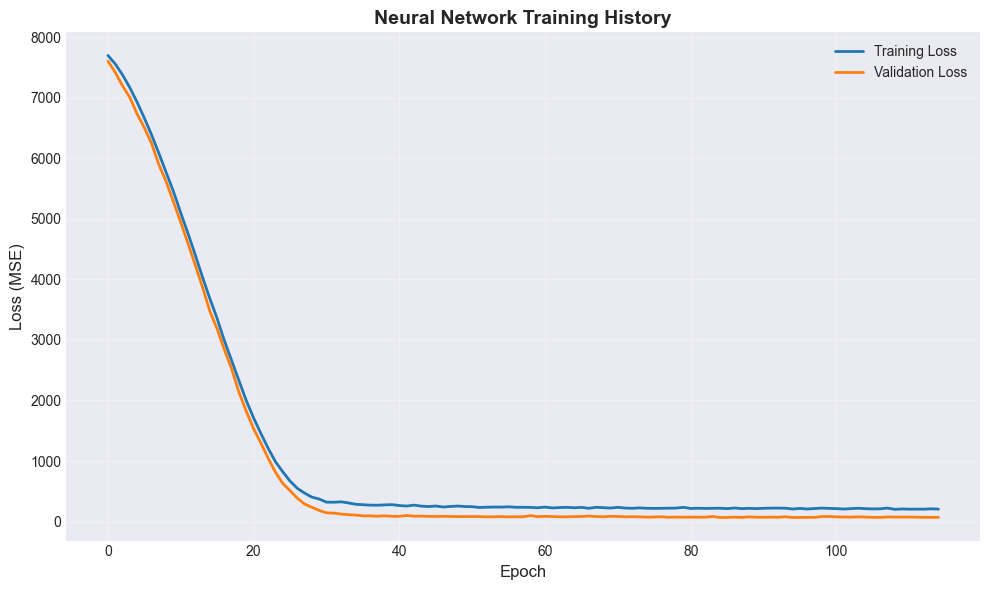

2025-10-09 14:25:45,598 - __main__ - INFO - Model comparison plot saved to output\model_comparison.png


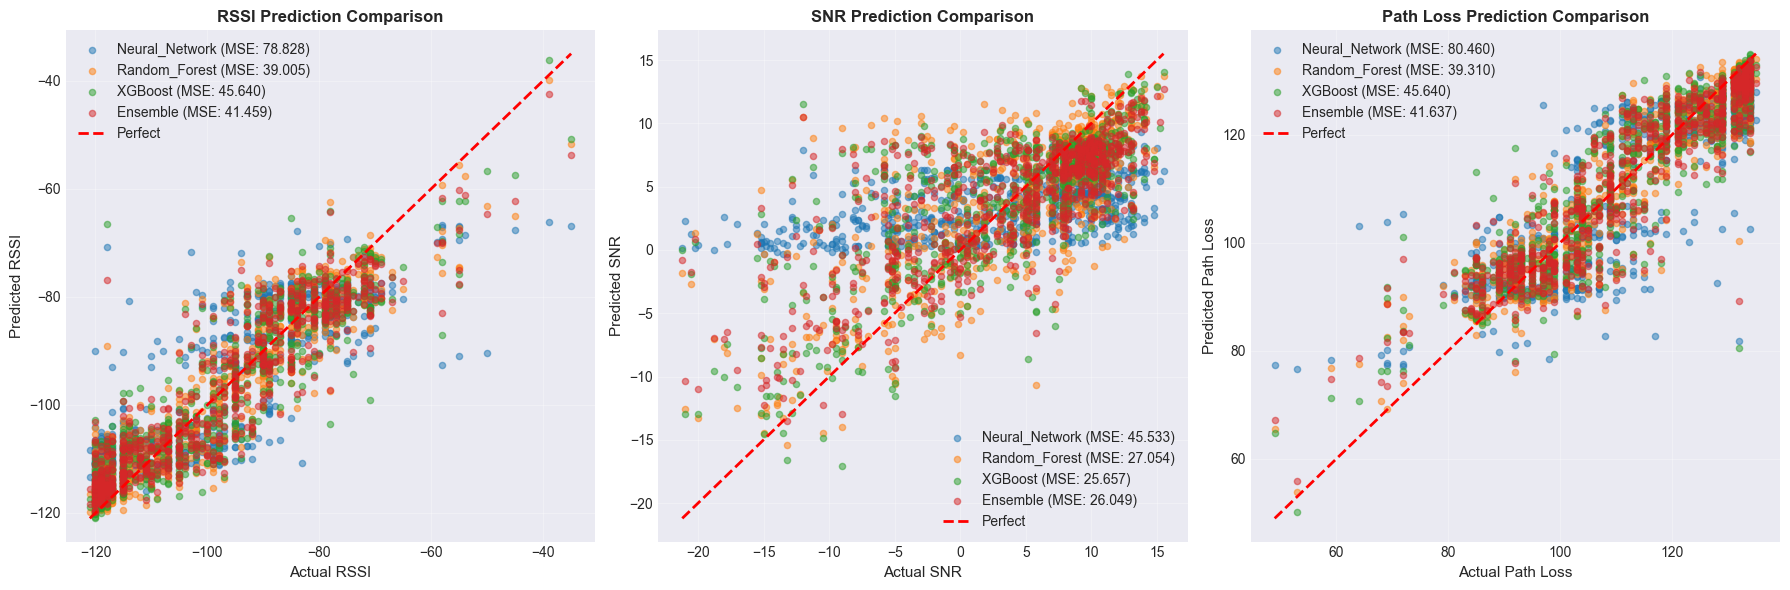

2025-10-09 14:25:46,163 - __main__ - INFO - 
2025-10-09 14:25:46,164 - __main__ - INFO - MODEL EVALUATION METRICS (MSE)
2025-10-09 14:25:46,165 - __main__ - INFO - ============================================================
2025-10-09 14:25:46,171 - __main__ - INFO - 
RSSI:
2025-10-09 14:25:46,172 - __main__ - INFO -   Neural_Network       - MSE: 78.8283, MAE: 7.0723, R²: 0.7260
2025-10-09 14:25:46,175 - __main__ - INFO -   Random_Forest        - MSE: 39.0051, MAE: 4.6234, R²: 0.8644
2025-10-09 14:25:46,176 - __main__ - INFO -   XGBoost              - MSE: 45.6401, MAE: 4.9932, R²: 0.8414
2025-10-09 14:25:46,177 - __main__ - INFO -   Ensemble             - MSE: 41.4586, MAE: 4.9021, R²: 0.8559
2025-10-09 14:25:46,178 - __main__ - INFO - 
SNR:
2025-10-09 14:25:46,179 - __main__ - INFO -   Neural_Network       - MSE: 45.5330, MAE: 5.4747, R²: 0.2168
2025-10-09 14:25:46,180 - __main__ - INFO -   Random_Forest        - MSE: 27.0539, MAE: 3.7534, R²: 0.5347
2025-10-09 14:25:46,182 - __main

Model evaluation completed
  - Generated: output/training_history.png
  - Generated: output/model_comparison.png


 4b. Saving Model Comparison to CSV...
  - Saved model comparison to: output/model_comparison.csv
Error saving model comparison: 'Neural Network'


 5. Running Path Optimization Example...
  Path: (5.0097, 97.0634) -> (5.1017, 97.2917)
  LoRa Parameters: SF=7, Freq=868.0MHz, TX Power=14.0dBm


2025-10-09 14:25:49,537 - googleapiclient.http - WARNING - Sleeping 0.54 seconds before retry 1 of 5 for request: POST https://earthengine.googleapis.com/v1/projects/ee-icr0x002/value:compute?prettyPrint=false&alt=json, after ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2025-10-09 14:26:26,198 - __main__ - INFO -   Progress: 50/285 (18%)
2025-10-09 14:26:55,767 - __main__ - INFO -   Progress: 100/285 (35%)
2025-10-09 14:27:25,802 - __main__ - INFO -   Progress: 150/285 (53%)
2025-10-09 14:27:55,130 - __main__ - INFO -   Progress: 200/285 (70%)
2025-10-09 14:28:25,545 - __main__ - INFO -   Progress: 250/285 (88%)
2025-10-09 14:28:46,934 - __main__ - INFO -  Completed: 285/285
2025-10-09 14:28:46,936 - __main__ - INFO - 
 Predicting metrics with user parameters...
2025-10-09 14:28:46,937 - __main__ - INFO -   Using SF7  SNR threshold: -7.5 dB
2025-10-09 14:28:47,886 - __main__ - INFO -  Predictions completed
2025-10-09 14:28:47,889 - __main

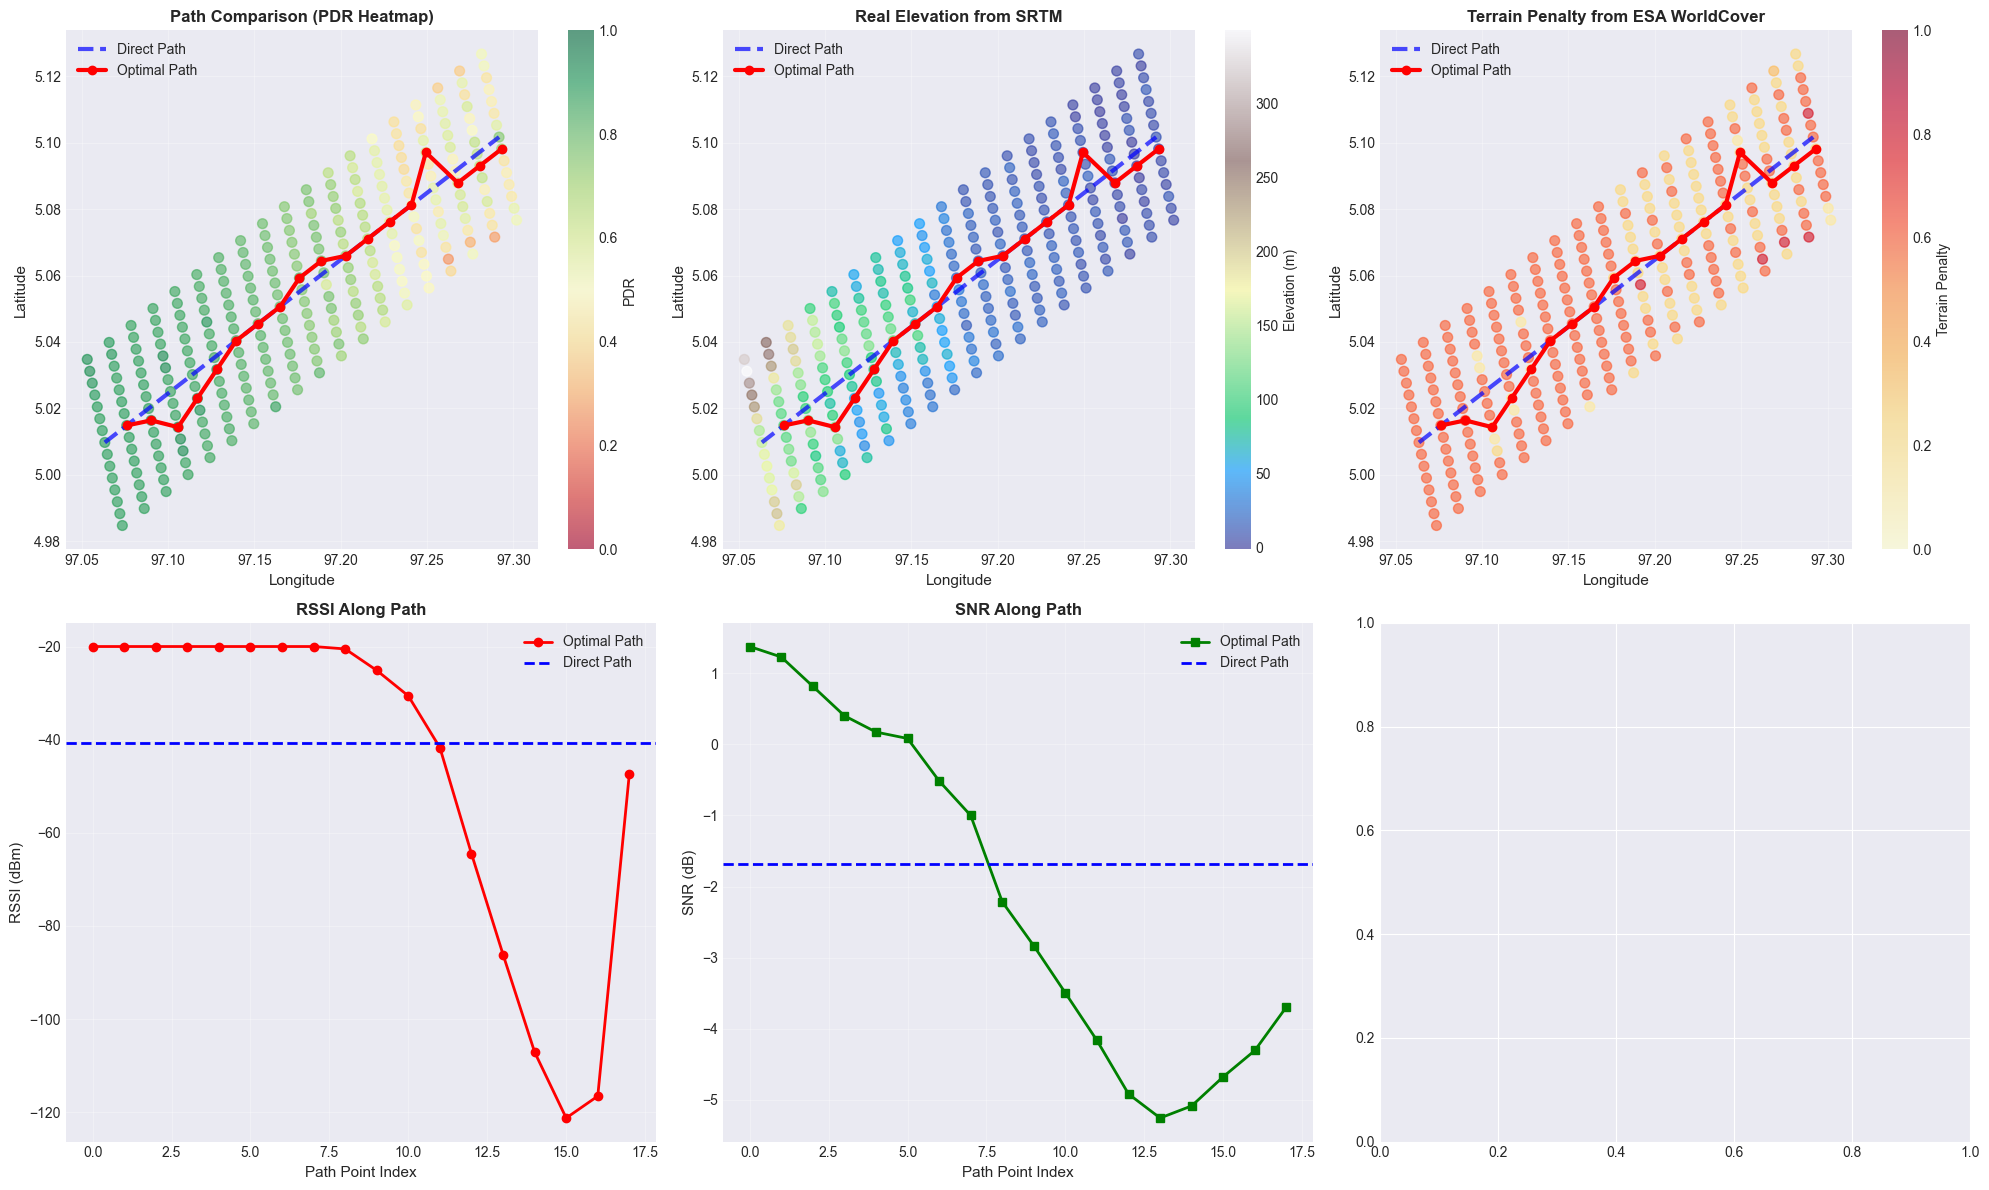

2025-10-09 14:28:51,848 - __main__ - INFO - 
Creating HTML visualization: path_optimization.html
2025-10-09 14:28:52,254 - __main__ - INFO - HTML map saved to output\path_optimization.html



PATH OPTIMIZATION SUMMARY

Direct Path:
  Average RSSI: -40.65 dBm
  Average SNR:  -1.68 dB
  Average PDR:  0.7499 (74.99%)

Optimal Path:
  Average RSSI: -45.60 dBm
  Average SNR:  -2.12 dB
  Average PDR:  0.7624 (76.24%)
  Path length:  18 waypoints
  Avg Elevation: 46.8 m (from SRTM)
  Avg Terrain Penalty: 0.328 (from ESA WorldCover)

Improvements:
  RSSI: -4.95 dBm (-12.18%)
  SNR:  -0.43 dB (-25.83%)
  PDR:  +1.24%

  - Saved optimal path to: output/optimal_path.csv
  - Saved direct path metrics to: output/direct_path_metrics.csv
  - Saved grid points to: output/grid_points.csv
Path optimization completed
  - Optimal path: 18 waypoints
  - Generated: output/path_comparison.png
  - Generated: output/path_optimization.html


In [3]:
def main():
    """Main function to run the complete LoRa path optimization system with REAL data"""
    print("="*60)
    print("LoRa Path Optimization System with Real Data")
    print("="*60)
    
    # Create output directory if it doesn't exist
    output_dir = Path("./output")
    output_dir.mkdir(exist_ok=True)
    
    # ========================================
    # STEP 1: INITIALIZE THE SYSTEM
    # ========================================
    print("\n\n 1. Initializing LoRa System...")
    
    # Create the main system object
    lora_system = LoRaSystem()
    
    # Check if Google Earth Engine is available
    if lora_system.gee.initialized:
        print("Google Earth Engine initialized successfully")
        print("  - Using real elevation data from SRTM (30m resolution)")
        print("  - Using real land cover data from ESA WorldCover (10m resolution)")
    else:
        print("Google Earth Engine not available")
    
    # ========================================
    # STEP 2: LOAD AND PREPROCESS REAL DATA
    # ========================================
    print("\n\n 2. Loading and Preprocessing Real Data...")
    
    try:
        # Load real datasets
        X_train, X_test, y_train, y_test, feature_cols = lora_system.load_and_preprocess_data()
        print(f"Loaded {len(X_train)} training samples and {len(X_test)} test samples")
        print(f"Features: {feature_cols}")
        
    except Exception as e:
        print(f"Error loading real data: {e}")
        print("\nPlease ensure you have real data files in the '../data' directory:")
        print("  - processed_data_1.csv")
        print("  - processed_data_2.csv")
        print("\nYour real data should include these columns:")
        print("  Required: latitude, longitude, RSSI, SNR, PDR")
        print("  Optional: elevation, land_cover, terrain_penalty, spreading_factor, frequency, tx_power")
        print("  If missing, elevation/land_cover will be fetched from Google Earth Engine")
        return
    
    # ========================================
    # STEP 3: TRAIN MACHINE LEARNING MODELS
    # ========================================
    print("\n\n 3. Training Machine Learning Models...")
    
    try:
        # Train all three models: Neural Network, Random Forest, XGBoost
        train_result = lora_system.train_models_with_auto_selection(
            X_train, X_test, y_train, y_test, feature_cols
        )
        
        # Check how many values were returned
        if len(train_result) == 4:
            predictions_dict, y_test, feature_cols, nn_trainer = train_result
        else:
            # If not 4 values, unpack accordingly
            predictions_dict, y_test, feature_cols = train_result
            nn_trainer = None
            print("Warning: train_models did not return nn_trainer")
        
        print("Successfully trained all models")
        
    except Exception as e:
        print(f"Error training models: {e}")
        return
    
    # ========================================
    # STEP 4: EVALUATE MODELS
    # ========================================
    print("\n\n 4. Evaluating Model Performance...")
    
    try:
        # Compare model performances and generate visualizations
        lora_system.evaluate_models(predictions_dict, y_test, feature_cols, nn_trainer)
        print("Model evaluation completed")
        print(f"  - Generated: {output_dir}/training_history.png")
        print(f"  - Generated: {output_dir}/model_comparison.png")
        
    except Exception as e:
        print(f"Error evaluating models: {e}")
        return
    
    # ========================================
    # STEP 4b: SAVE MODEL COMPARISON TO CSV
    # ========================================
    print("\n\n 4b. Saving Model Comparison to CSV...")
    
    try:
        # Create model comparison dataframe
        comparison_data = []
        metrics = ['RSSI', 'SNR', 'Path Loss']
    
        for i, metric in enumerate(metrics):
            for model_name, predictions in predictions_dict.items():
                mse = np.mean((y_test[:, i] - predictions[:, i])**2)
                mae = np.mean(np.abs(y_test[:, i] - predictions[:, i]))
                rmse = np.sqrt(mse)
                r2 = 1 - np.sum((y_test[:, i] - predictions[:, i])**2) / np.sum((y_test[:, i] - np.mean(y_test[:, i]))**2)
                
                comparison_data.append({
                    'Metric': metric,
                    'Model': model_name,
                    'MSE': mse,
                    'RMSE': rmse,
                    'MAE': mae,
                    'R2_Score': r2
                })
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df.to_csv(output_dir / 'model_comparison.csv', index=False)
        print(f"  - Saved model comparison to: {output_dir}/model_comparison.csv")
        
        # Also save detailed predictions
        predictions_detailed = pd.DataFrame({
            'Actual_RSSI': y_test[:, 0],
            'Actual_SNR': y_test[:, 1],
            'Actual_PathLoss': y_test[:, 2],
            'NN_RSSI': predictions_dict['Neural Network'][:, 0],
            'NN_SNR': predictions_dict['Neural Network'][:, 1],
            'NN_PathLoss': predictions_dict['Neural Network'][:, 2],
            'RF_RSSI': predictions_dict['Random Forest'][:, 0],
            'RF_SNR': predictions_dict['Random Forest'][:, 1],
            'RF_PathLoss': predictions_dict['Random Forest'][:, 2],
            'XGB_RSSI': predictions_dict['XGBoost'][:, 0],
            'XGB_SNR': predictions_dict['XGBoost'][:, 1],
            'XGB_PathLoss': predictions_dict['XGBoost'][:, 2],
        })
        predictions_detailed.to_csv(output_dir / 'detailed_predictions.csv', index=False)
        print(f"  - Saved detailed predictions to: {output_dir}/detailed_predictions.csv")
        
    except Exception as e:
        print(f"Error saving model comparison: {e}")
    
    # ========================================
    # STEP 5: PATH OPTIMIZATION
    # ========================================
    print("\n\n 5. Running Path Optimization Example...")
    
    try:
        # Define coordinates for path optimization
        start_lat, start_lon = 5.009745, 97.063413
        dest_lat, dest_lon = 5.1017, 97.2917
        
        # Define LoRa communication parameters
        lora_params = LoRaParameters(
            tx_power=14.0,
            spreading_factor=7,
            frequency=868.0,
            bandwidth=125.0,
            coding_rate=4
        )
        
        print(f"  Path: ({start_lat:.4f}, {start_lon:.4f}) -> ({dest_lat:.4f}, {dest_lon:.4f})")
        print(f"  LoRa Parameters: SF={lora_params.spreading_factor}, "
              f"Freq={lora_params.frequency}MHz, TX Power={lora_params.tx_power}dBm")
        
        # Create a wrapper for the neural network model
        class ModelWrapper:
            def __init__(self, model, device):
                self.model = model
                self.device = device
            def predict(self, X):
                self.model.eval()
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X).to(self.device)
                    predictions = self.model(X_tensor).cpu().numpy()
                return predictions
        
        # Initialize path optimizer
        wrapper = ModelWrapper(lora_system.models['neural_network'], lora_system.device)
        optimizer = PathOptimizer(
            wrapper, 
            lora_system.scalers['feature'], 
            feature_cols,
            lora_system.gee
        )
        
        # Run path optimization
        optimal_path, grid_points = optimizer.find_optimal_path(
            start_lat, start_lon, dest_lat, dest_lon,
            lora_params, OptimizationConfig()
        )
        
        # Sample direct path for comparison
        direct_path_metrics = optimizer.sample_direct_path(
            start_lat, start_lon, dest_lat, dest_lon, lora_params, num_samples=10
        )
        
        # ===== FIX: Generate visualizations (PNG and HTML) =====
        visualizer = ResultVisualizer()
        
        # Generate PNG visualization
        visualizer.plot_path_comparison(optimal_path, direct_path_metrics, grid_points)
        
        # Generate HTML interactive map
        visualizer.visualize_path_html_fixed(
            optimal_path, 
            direct_path_metrics, 
            grid_points,
            start_lat, start_lon, dest_lat, dest_lon,
            filename='path_optimization.html'
        )
        
        # Print summary
        visualizer.print_path_summary(optimal_path, direct_path_metrics)
        
        # Save optimal path to CSV
        optimal_path_data = []
        for i, point in enumerate(optimal_path):
            optimal_path_data.append({
                'point_id': i,
                'latitude': point.lat,
                'longitude': point.lon,
                'elevation': point.elevation,
                'land_cover': point.land_cover,
                'terrain_penalty': point.terrain_penalty,
                'distance_to_start': point.distance_to_start,
                'distance_to_destination': point.distance_to_destination,
                'RSSI': point.rssi,
                'SNR': point.snr,
                'PDR': point.pdr,
                'path_loss': point.path_loss
            })
        
        optimal_path_df = pd.DataFrame(optimal_path_data)
        optimal_path_df.to_csv(output_dir / 'optimal_path.csv', index=False)
        print(f"  - Saved optimal path to: {output_dir}/optimal_path.csv")
        
        # Save direct path metrics to CSV
        direct_path_df = pd.DataFrame([direct_path_metrics])
        direct_path_df.to_csv(output_dir / 'direct_path_metrics.csv', index=False)
        print(f"  - Saved direct path metrics to: {output_dir}/direct_path_metrics.csv")
        
        # Save grid points to CSV
        grid_data = []
        for i, point in enumerate(grid_points):
            grid_data.append({
                'point_id': i,
                'latitude': point.lat,
                'longitude': point.lon,
                'elevation': point.elevation,
                'land_cover': point.land_cover,
                'terrain_penalty': point.terrain_penalty,
                'RSSI': point.rssi,
                'SNR': point.snr,
                'PDR': point.pdr,
                'path_loss': point.path_loss
            })
        
        grid_df = pd.DataFrame(grid_data)
        grid_df.to_csv(output_dir / 'grid_points.csv', index=False)
        print(f"  - Saved grid points to: {output_dir}/grid_points.csv")
        
        print(f"Path optimization completed")
        print(f"  - Optimal path: {len(optimal_path)} waypoints")
        print(f"  - Generated: {output_dir}/path_comparison.png")
        print(f"  - Generated: {output_dir}/path_optimization.html")  # <=== ADDED
        
    except Exception as e:
        print(f"Error in path optimization: {e}")
        import traceback
        traceback.print_exc()
    """"
    # ========================================
    # STEP 6: MULTI-HOP ROUTING 
    # ========================================
    print("\n\n 6. Running Multi-hop Routing Example...")
    
    try:
        # Define longer distance for multi-hop
        far_lat, far_lon = 41.8781, -87.6298
        
        print(f"  Multi-hop path: ({start_lat:.4f}, {start_lon:.4f}) -> ({far_lat:.4f}, {far_lon:.4f})")
        
        # Initialize multi-hop router
        router = MultiHopRouter(
            wrapper,  # Use the same wrapper
            lora_system.scalers['feature'],
            feature_cols,
            lora_system.gee
        )
        
        # Run multi-hop routing
        multi_hop_path = router.find_relay_nodes(
            start_lat, start_lon, far_lat, far_lon,
            max_hop_distance_km=5.0,
            min_relay_distance_km=1.0,
            lora_params=lora_params,
            config=OptimizationConfig()
        )
        
        # Save multi-hop path to CSV
        all_hops_data = []
        for hop in multi_hop_path:
            for i, point in enumerate(hop['path']):
                all_hops_data.append({
                    'hop_number': hop['hop_number'],
                    'point_id': i,
                    'latitude': point.lat,
                    'longitude': point.lon,
                    'elevation': point.elevation,
                    'land_cover': point.land_cover,
                    'terrain_penalty': point.terrain_penalty,
                    'distance_to_start': point.distance_to_start,
                    'distance_to_destination': point.distance_to_destination,
                    'RSSI': point.rssi,
                    'SNR': point.snr,
                    'PDR': point.pdr,
                    'path_loss': point.path_loss,
                    'is_relay': point.is_relay
                })
        
        multi_hop_df = pd.DataFrame(all_hops_data)
        multi_hop_df.to_csv(output_dir / 'multi_hop_path.csv', index=False)
        print(f"  - Saved multi-hop path to: {output_dir}/multi_hop_path.csv")
        
        # ===== FIX: Visualize multi-hop path as HTML =====
        router.visualize_multi_hop(multi_hop_path, filename='multi_hop_routing.html')
        
        print(f"Multi-hop routing completed")
        print(f"  - Generated: {output_dir}/multi_hop_routing.html")  # <=== ADDED
        
    except Exception as e:
        print(f"Error in multi-hop routing: {e}")
        import traceback
        traceback.print_exc()
    
    # ========================================
    # STEP 7: COVERAGE MAP GENERATION
    # ========================================
    print("\n\n 7. Generating Coverage Map...")
    
    try:
        # Initialize coverage map generator
        coverage_generator = CoverageMapGenerator(
            lora_system.models['neural_network'],
            lora_system.scalers['feature'],
            feature_cols,
            lora_system.gee
        )
        
        # Generate coverage map around the start point
        coverage_data = coverage_generator.generate_coverage_map(
            center_lat=start_lat,
            center_lon=start_lon,
            lora_params=lora_params,
            radius_km=10,      # 10 km radius
            grid_resolution=30,  # 30x30 grid
            filename=str(output_dir / 'coverage_map.html')
        )
        
        # Coverage data is already saved to CSV in the generate_coverage_map method
        print(f"Coverage map generated")
        print(f"  - Grid: 30x30 = 900 points")
        print(f"  - Radius: 10 km")
        print(f"  - Generated: {output_dir}/coverage_map.html")
        print(f"  - Generated: {output_dir}/coverage_map_data.csv")
        
    except Exception as e:
        print(f"Error generating coverage map: {e}")
    
    # ========================================
    # STEP 8: FINAL SUMMARY
    # ========================================
    print("\n\n\n" + "="*60)
    print("SYSTEM EXECUTION COMPLETED SUCCESSFULLY")
    print("="*60)
    print("\nGenerated Files:")
    print(f"  {output_dir}/training_history.png - Neural network training progress")
    print(f"  {output_dir}/model_comparison.png - Performance comparison of all models")
    print(f"  {output_dir}/model_comparison.csv - Model metrics comparison (CSV)")
    print(f"  {output_dir}/detailed_predictions.csv - Detailed predictions (CSV)")
    print(f"  {output_dir}/path_comparison.png - Optimal vs direct path visualization")
    print(f"  {output_dir}/path_optimization.html - Interactive optimized path map")
    print(f"  {output_dir}/multi_hop_routing.html - Interactive multi-hop routing map")
    print(f"  {output_dir}/coverage_map.html - Signal coverage heatmap")
    print(f"  {output_dir}/coverage_map_data.csv - Coverage data in CSV format")
    print(f"  {output_dir}/optimal_path.csv - Optimal path points with metrics")
    print(f"  {output_dir}/direct_path_metrics.csv - Direct path metrics")
    print(f"  {output_dir}/grid_points.csv - All evaluated grid points")
    print(f"  {output_dir}/multi_hop_path.csv - Multi-hop path points with metrics")
    print("\n" + "="*60)
    """
# ========================================
# EXECUTE THE MAIN FUNCTION
# ========================================
if __name__ == "__main__":
    # Run the complete system
    main()